In [1]:
import json 
import os
import requests #type: ignore
from datetime import datetime
import sys

import SRC
metadata = SRC.load_model_metadata()
from SRC.helpFolder import *

### Load the **dataframes** 

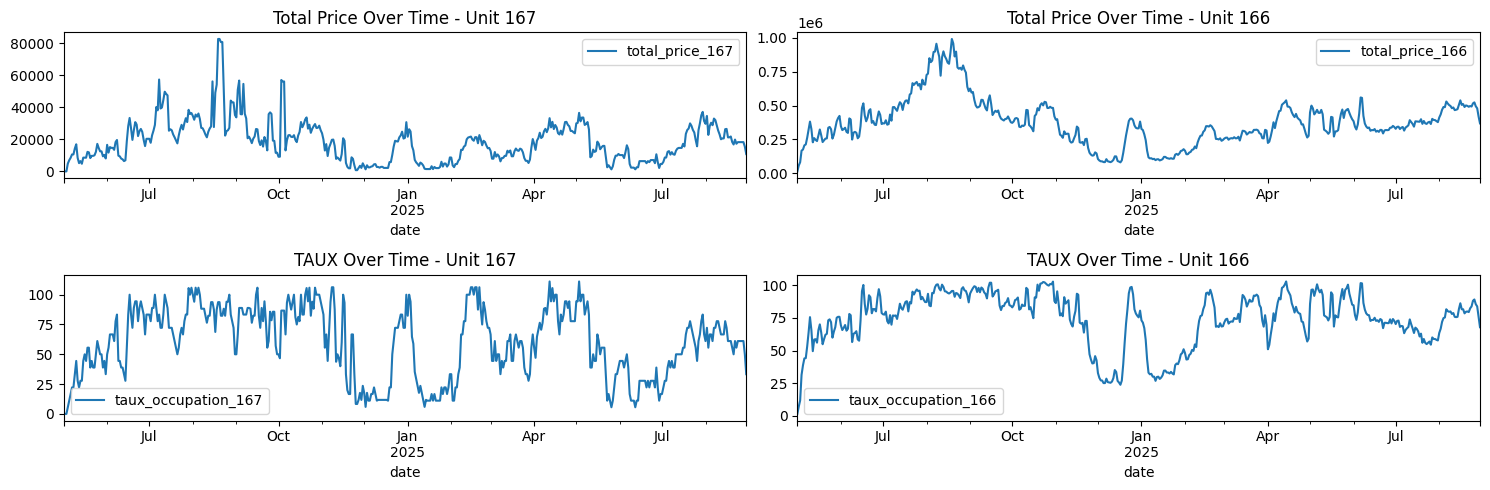

In [2]:
df_167, df_166 = prepare_and_plot_data(
    csv_path = metadata['PMSInformation']['final_csv_path'],
    start_date = metadata['PMSInformation']['start_date_range'],
    end_date = metadata['PMSInformation']['end_date_range']
)

#### Train the LR model using the **new data**

--- Starting Linear Regression Pipeline for Unit 166 ---
Target type: taux (predicting occupancy rate)

[Step 1/3] Splitting data with test_size=0.2...
Split complete. Test size: 0.20
Target column: taux_occupation_166
Training set range: 2024-05-01 00:00:00 to 2025-05-24 00:00:00 (389 samples)
Testing set range: 2025-05-25 00:00:00 to 2025-08-30 00:00:00 (98 samples)

[Step 2/3] Training and evaluating Linear Regression model...

Training Linear Regression model for target: taux_occupation_166
Features used (X): ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'total_price_166']
Training set size: 389 samples
Testing set size: 98 samples

Model Evaluation Metrics:
Train RMSE: 12.73
Test RMSE: 17.77
Train MAE: 10.57
Test MAE: 15.01
Train R²: 0.6630
Test R²: -1.7760

Feature Importance (Coefficients):
           Feature  Coefficient
2             year    16.605963
1            month    -4.270921
0        dayofweek     0.207136
3        dayofyear     0.197075
4       weekofyear 

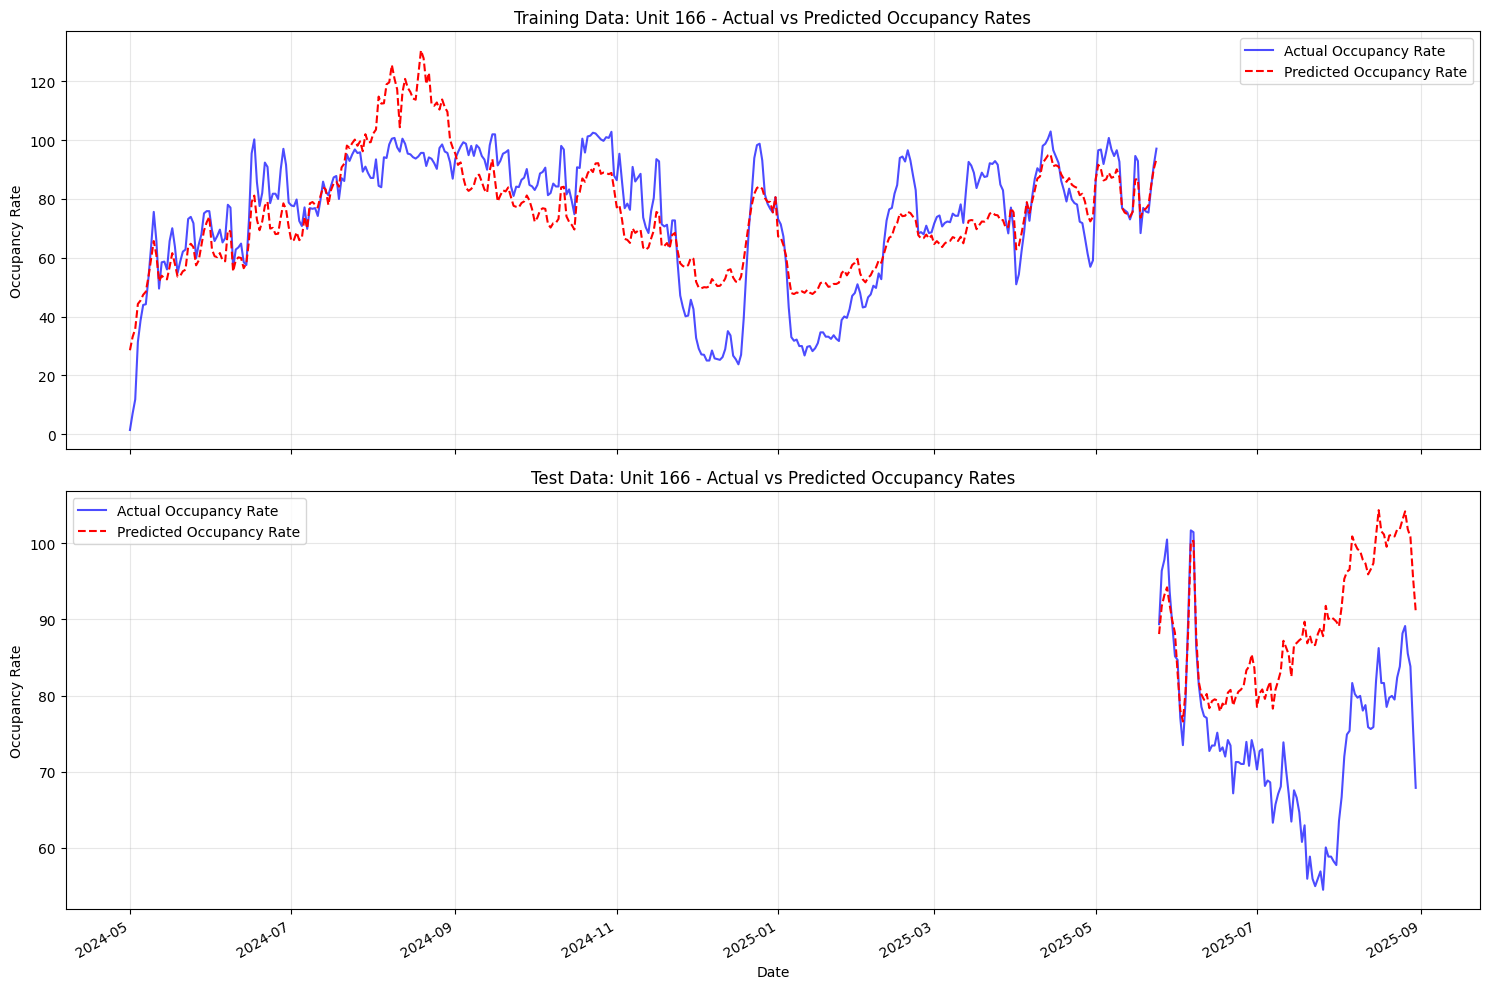

Plotting predictions on the full unit DataFrame...
Columns used for prediction: ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'total_price_166']
Target column: taux_occupation_166


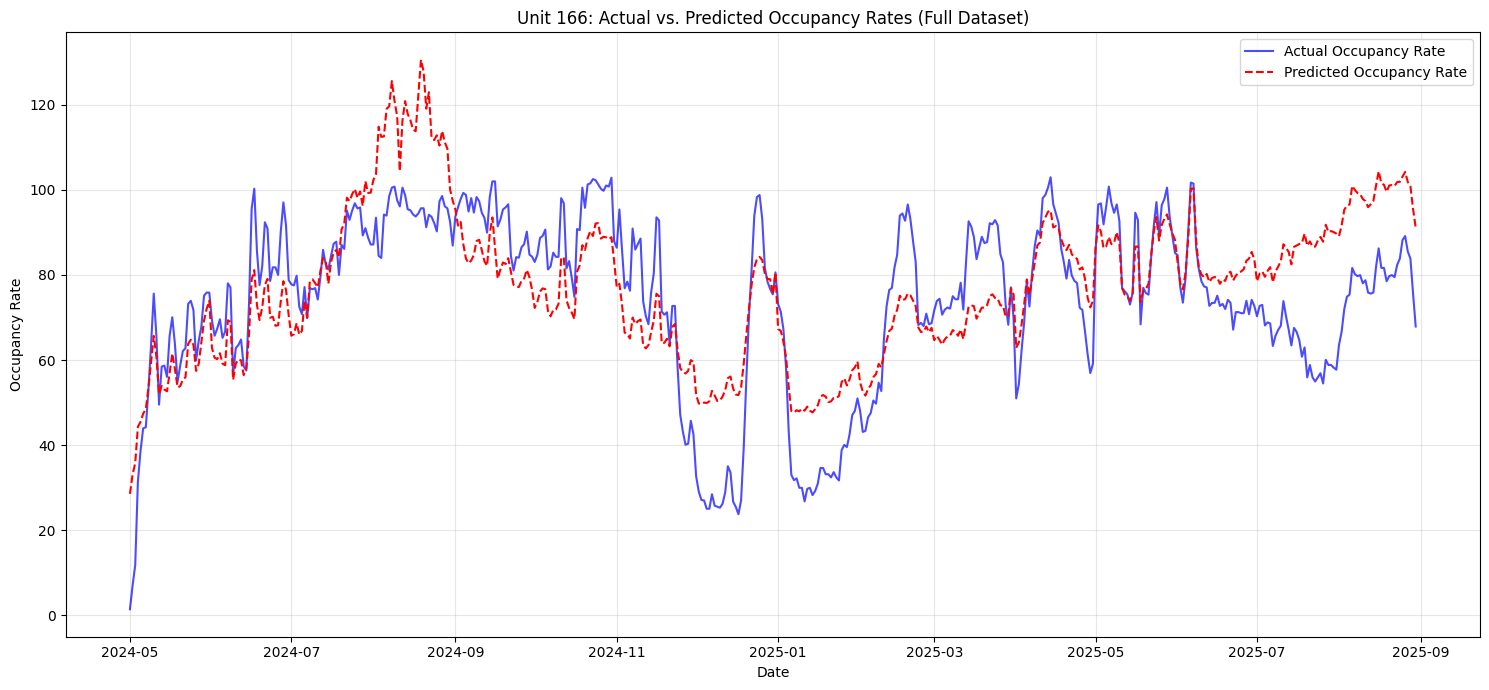


Pipeline finished for Unit 166.
--- End Linear Regression Pipeline ---
--- Starting Linear Regression Pipeline for Unit 167 ---
Target type: taux (predicting occupancy rate)

[Step 1/3] Splitting data with test_size=0.2...
Split complete. Test size: 0.20
Target column: taux_occupation_167
Training set range: 2024-05-01 00:00:00 to 2025-05-24 00:00:00 (389 samples)
Testing set range: 2025-05-25 00:00:00 to 2025-08-30 00:00:00 (98 samples)

[Step 2/3] Training and evaluating Linear Regression model...

Training Linear Regression model for target: taux_occupation_167
Features used (X): ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'total_price_167']
Training set size: 389 samples
Testing set size: 98 samples

Model Evaluation Metrics:
Train RMSE: 19.74
Test RMSE: 19.51
Train MAE: 15.87
Test MAE: 17.95
Train R²: 0.5610
Test R²: 0.1319

Feature Importance (Coefficients):
           Feature  Coefficient
2             year     9.941867
1            month    -2.560423
0        day

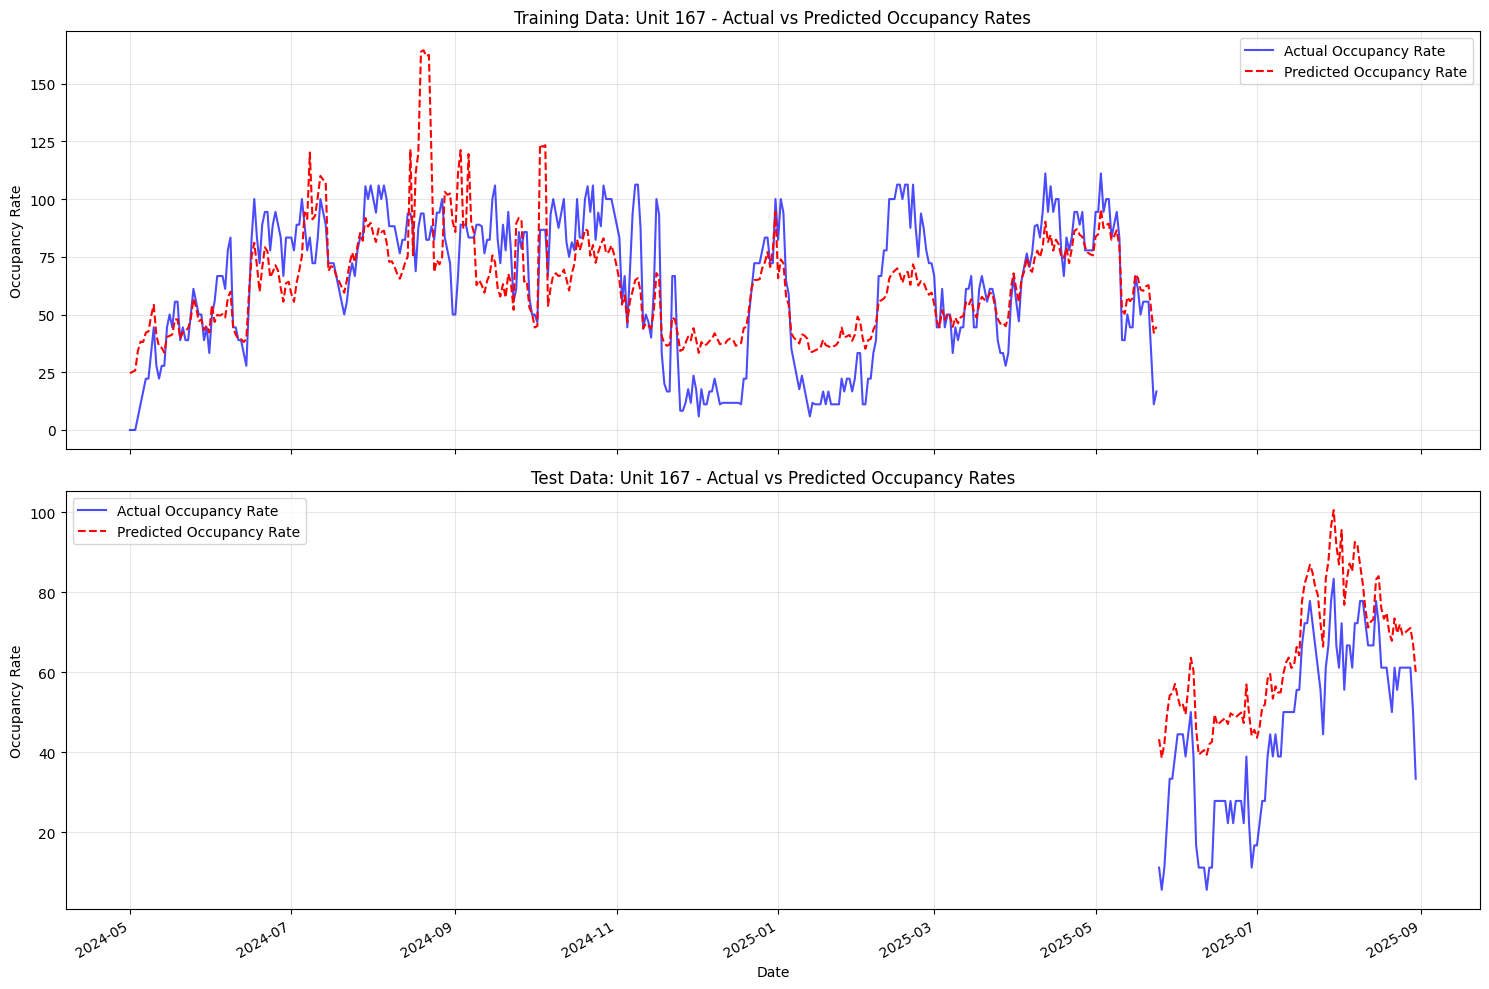

Plotting predictions on the full unit DataFrame...
Columns used for prediction: ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'total_price_167']
Target column: taux_occupation_167


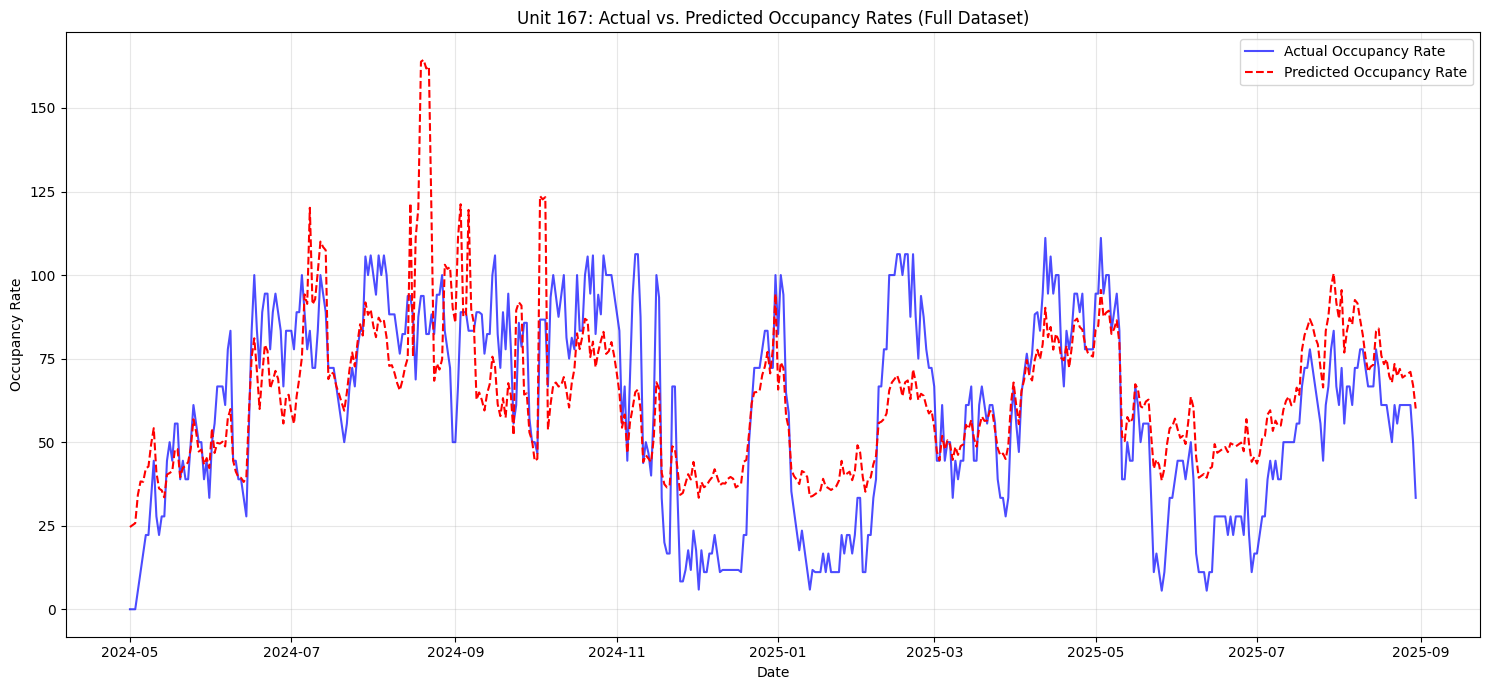


Pipeline finished for Unit 167.
--- End Linear Regression Pipeline ---


In [3]:
results_rl_taux_166 = run_linear_regression_pipeline(df_166, unit_id='166', target_type='taux')
results_rl_taux_167 = run_linear_regression_pipeline(df_167, unit_id='167', target_type='taux')

In [4]:
metadata['LinearRegressionModelsV2']

{'taux_166': {'folder_path': '../TrainedModels/UnitsBasedModelsV2/PredictTaux/LinearRegression',
  'model_name': 'linear_regression_v2_model_166'},
 'taux_167': {'folder_path': '../TrainedModels/UnitsBasedModelsV2/PredictTaux/LinearRegression',
  'model_name': 'linear_regression_v2_model_167'},
 'price_166': {'folder_path': '../TrainedModels/UnitsBasedModelsV2/PredictPrice/LinearRegression',
  'model_name': 'linear_model_v2_166'},
 'price_167': {'folder_path': '../TrainedModels/UnitsBasedModelsV2/PredictPrice/LinearRegression',
  'model_name': 'linear_model_v2_167'}}

In [5]:
save_lr_model(
    results_rl_taux_166,
    metadata['LinearRegressionModelsV2']['taux_166']['folder_path'], 
    metadata['LinearRegressionModelsV2']['taux_166']['model_name']
)

save_lr_model(
    results_rl_taux_167, 
    metadata['LinearRegressionModelsV2']['taux_167']['folder_path'],
    metadata['LinearRegressionModelsV2']['taux_167']['model_name']
)

Created directory: ../TrainedModels/UnitsBasedModelsV2/PredictTaux/LinearRegression
Model successfully saved to ../TrainedModels/UnitsBasedModelsV2/PredictTaux/LinearRegression\linear_regression_v2_model_166.pkl
Model successfully saved to ../TrainedModels/UnitsBasedModelsV2/PredictTaux/LinearRegression\linear_regression_v2_model_167.pkl


'../TrainedModels/UnitsBasedModelsV2/PredictTaux/LinearRegression\\linear_regression_v2_model_167.pkl'

--- Starting Linear Regression Pipeline for Unit 166 ---
Target type: price (predicting price)

[Step 1/3] Splitting data with test_size=0.2...
Split complete. Test size: 0.20
Target column: total_price_166
Training set range: 2024-05-01 00:00:00 to 2025-05-24 00:00:00 (389 samples)
Testing set range: 2025-05-25 00:00:00 to 2025-08-30 00:00:00 (98 samples)

[Step 2/3] Training and evaluating Linear Regression model...

Training Linear Regression model for target: total_price_166
Features used (X): ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'taux_occupation_166']
Training set size: 389 samples
Testing set size: 98 samples

Model Evaluation Metrics:
Train RMSE: 107711.89
Test RMSE: 165665.26
Train MAE: 80335.83
Test MAE: 145688.16
Train R²: 0.6827
Test R²: -4.2263

Feature Importance (Coefficients):
               Feature    Coefficient
2                 year -167956.019283
1                month   10831.981900
5  taux_occupation_166    6777.930828
3            dayofyear  

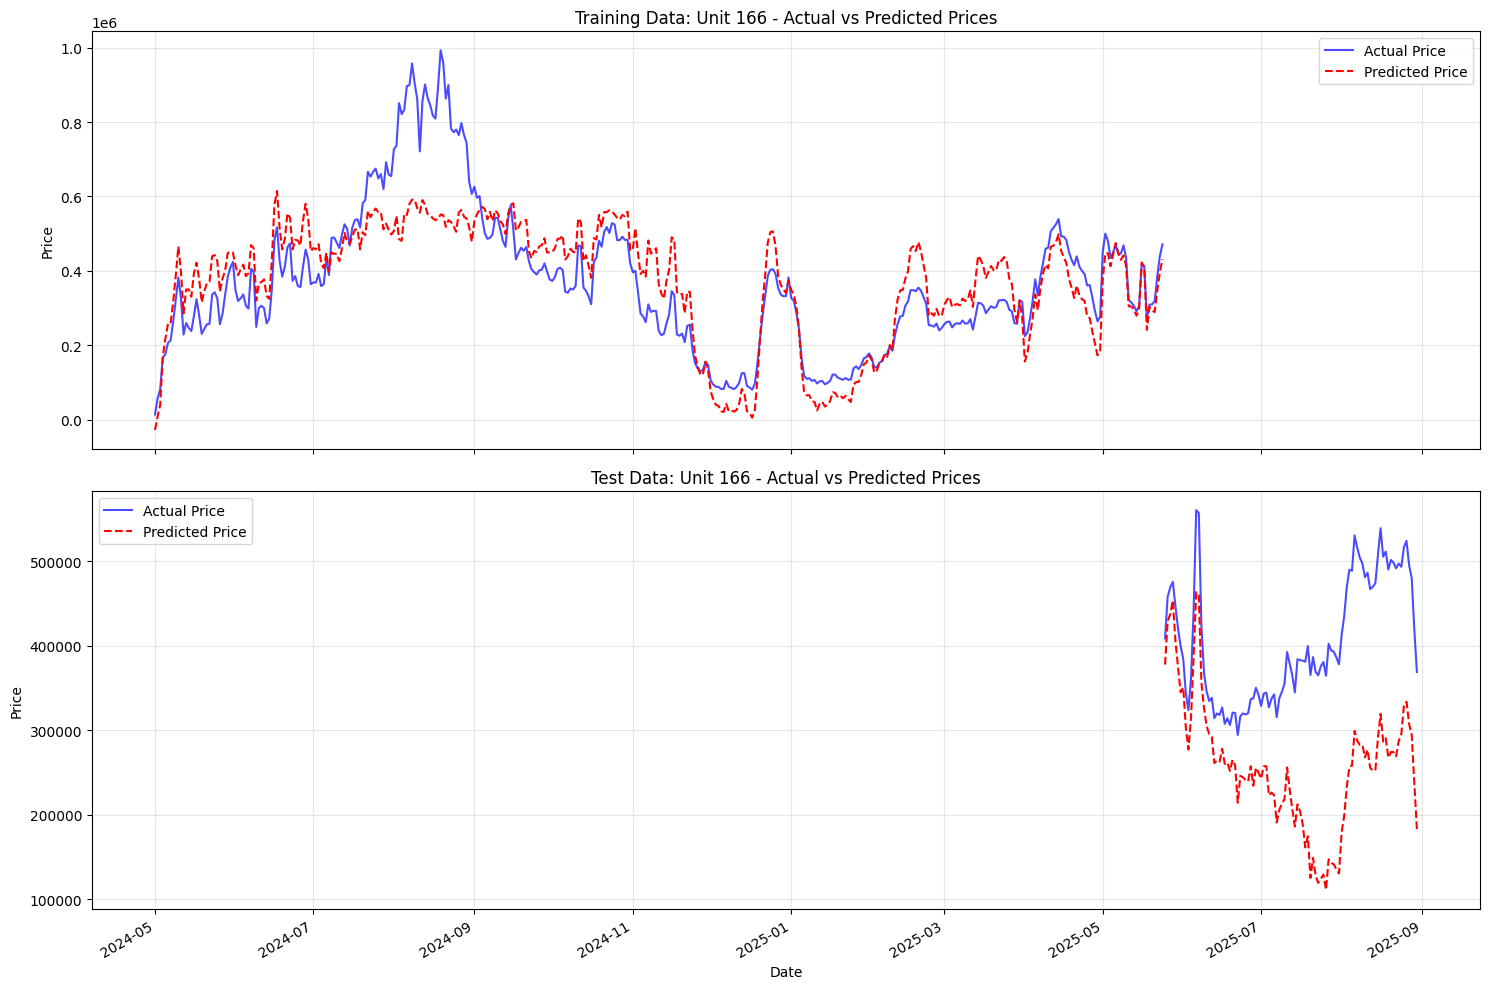

Plotting predictions on the full unit DataFrame...
Columns used for prediction: ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'taux_occupation_166']
Target column: total_price_166


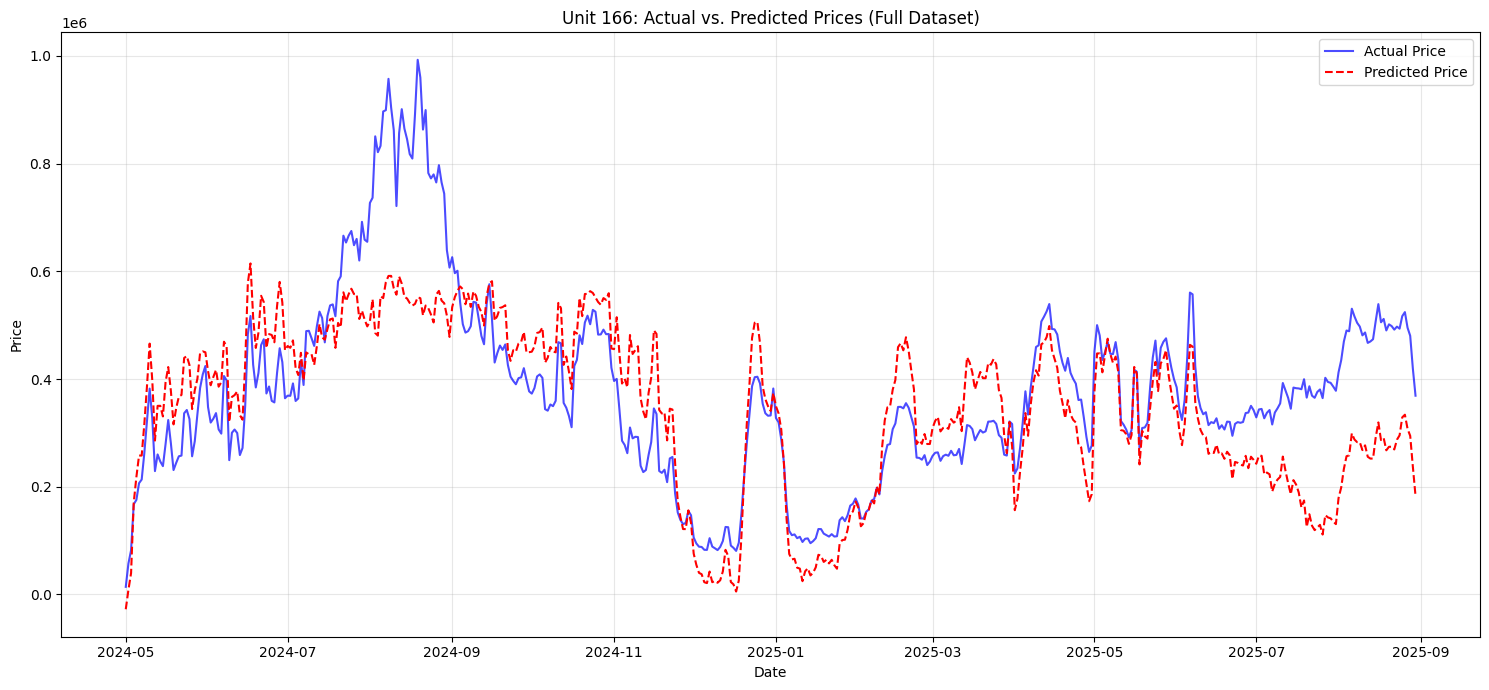


Pipeline finished for Unit 166.
--- End Linear Regression Pipeline ---
--- Starting Linear Regression Pipeline for Unit 167 ---
Target type: price (predicting price)

[Step 1/3] Splitting data with test_size=0.2...
Split complete. Test size: 0.20
Target column: total_price_167
Training set range: 2024-05-01 00:00:00 to 2025-05-24 00:00:00 (389 samples)
Testing set range: 2025-05-25 00:00:00 to 2025-08-30 00:00:00 (98 samples)

[Step 2/3] Training and evaluating Linear Regression model...

Training Linear Regression model for target: total_price_167
Features used (X): ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'taux_occupation_167']
Training set size: 389 samples
Testing set size: 98 samples

Model Evaluation Metrics:
Train RMSE: 8975.99
Test RMSE: 7218.37
Train MAE: 5487.73
Test MAE: 6178.90
Train R²: 0.5747
Test R²: 0.4146

Feature Importance (Coefficients):
               Feature  Coefficient
2                 year -6260.257820
1                month   976.171082
5  t

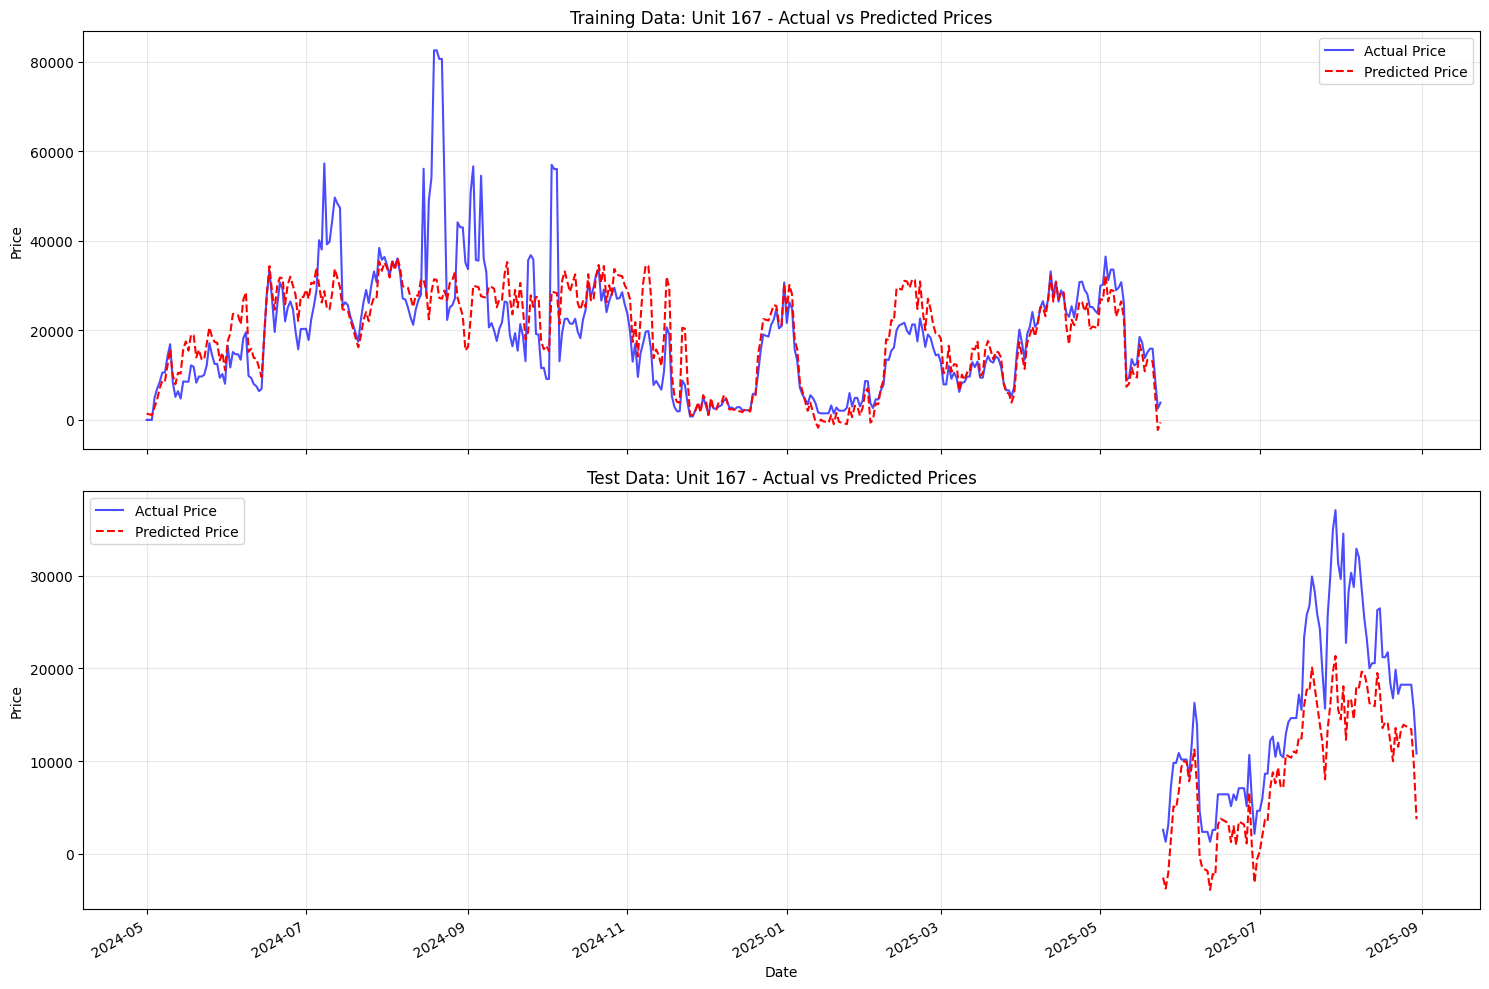

Plotting predictions on the full unit DataFrame...
Columns used for prediction: ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'taux_occupation_167']
Target column: total_price_167


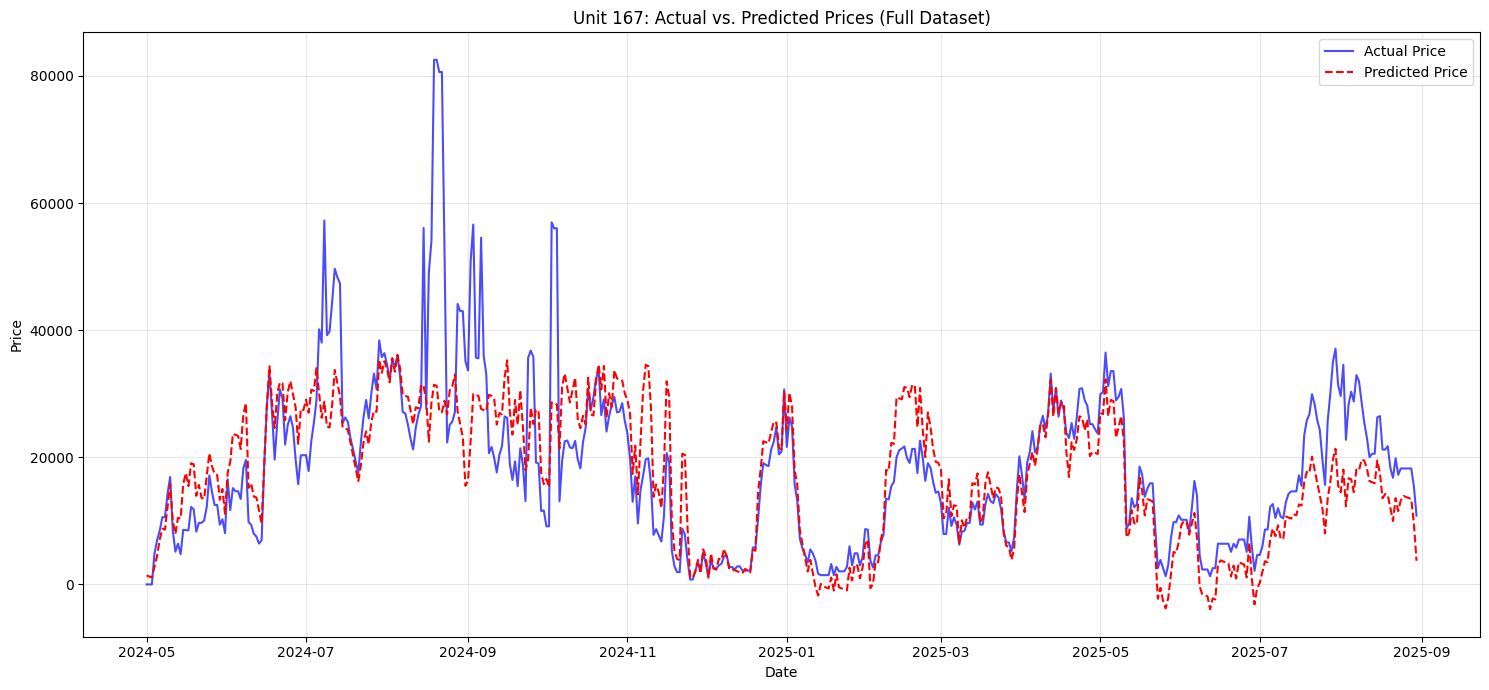


Pipeline finished for Unit 167.
--- End Linear Regression Pipeline ---


In [6]:
results_rl_price_166 = run_linear_regression_pipeline(df_166, unit_id='166', target_type='price')
results_rl_price_167 = run_linear_regression_pipeline(df_167, unit_id='167', target_type='price')

In [7]:
save_lr_model(
    results_rl_price_166,
    metadata['LinearRegressionModelsV2']['price_166']['folder_path'], 
    metadata['LinearRegressionModelsV2']['price_166']['model_name']
)

save_lr_model(
    results_rl_price_167, 
    metadata['LinearRegressionModelsV2']['price_167']['folder_path'],
    metadata['LinearRegressionModelsV2']['price_167']['model_name']
)

Created directory: ../TrainedModels/UnitsBasedModelsV2/PredictPrice/LinearRegression
Model successfully saved to ../TrainedModels/UnitsBasedModelsV2/PredictPrice/LinearRegression\linear_model_v2_166.pkl
Model successfully saved to ../TrainedModels/UnitsBasedModelsV2/PredictPrice/LinearRegression\linear_model_v2_167.pkl


'../TrainedModels/UnitsBasedModelsV2/PredictPrice/LinearRegression\\linear_model_v2_167.pkl'

In [ ]:
results = find_max_output_for_date_range_linear_model(
    start_date_str= '2025-04-20',
    end_date_str= '2025-04-30',
    unit_id='166',
    min_value= 30.0,
    max_value= 100.0,
    step=1,
    target_type='price',
    modelsName='LinearRegressionModelsV2'
)

Loading model for target='price', unit='166'...
Model name: linear_model_v2_166
Model successfully loaded from ../TrainedModels/UnitsBasedModelsV2/PredictPrice/LinearRegression\linear_model_v2_166.pkl
Model loaded successfully.

Searching for optimal taux_occupation for unit 166 on 2025-04-20
Range: 30.00-100.00, step: 1
Target: maximize predicted price


Testing taux_occupation values:  27%|██▋       | 19/71 [00:00<00:00, 185.74it/s]


Predicting total_price_166 for Unit 166 on 2025-04-20 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          6      4  2025        110          16                 30.0

Predicting total_price_166 for Unit 166 on 2025-04-20 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          6      4  2025        110          16                 31.0

Predicting total_price_166 for Unit 166 on 2025-04-20 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          6      4  2025        110          16                 32.0

Predicting total_price_166 for Unit 166 on 2025-04-20 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          6      4  2025        110          16                 33.0

Predicting total_price_166 for Unit 166 on 2025-04-20 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          6      4 

Testing taux_occupation values:  66%|██████▌   | 47/71 [00:00<00:00, 238.28it/s]


Predicting total_price_166 for Unit 166 on 2025-04-20 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          6      4  2025        110          16                 49.0

Predicting total_price_166 for Unit 166 on 2025-04-20 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          6      4  2025        110          16                 50.0

Predicting total_price_166 for Unit 166 on 2025-04-20 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          6      4  2025        110          16                 51.0

Predicting total_price_166 for Unit 166 on 2025-04-20 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          6      4  2025        110          16                 52.0

Predicting total_price_166 for Unit 166 on 2025-04-20 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          6      4 

...


Predicting total_price_166 for Unit 166 on 2025-04-30 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          2      4  2025        120          18                 30.0

Predicting total_price_166 for Unit 166 on 2025-04-30 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          2      4  2025        120          18                 31.0

Predicting total_price_166 for Unit 166 on 2025-04-30 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          2      4  2025        120          18                 32.0

Predicting total_price_166 for Unit 166 on 2025-04-30 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          2      4  2025        120          18                 33.0

Predicting total_price_166 for Unit 166 on 2025-04-30 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          2      4 

Testing taux_occupation values:  79%|███████▉  | 56/71 [00:00<00:00, 269.93it/s]


Predicting total_price_166 for Unit 166 on 2025-04-30 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          2      4  2025        120          18                 58.0

Predicting total_price_166 for Unit 166 on 2025-04-30 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          2      4  2025        120          18                 59.0

Predicting total_price_166 for Unit 166 on 2025-04-30 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          2      4  2025        120          18                 60.0

Predicting total_price_166 for Unit 166 on 2025-04-30 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          2      4  2025        120          18                 61.0

Predicting total_price_166 for Unit 166 on 2025-04-30 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          2      4 

Testing taux_occupation values: 100%|██████████| 71/71 [00:00<00:00, 268.37it/s]


Predicting total_price_166 for Unit 166 on 2025-04-30 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          2      4  2025        120          18                 86.0

Predicting total_price_166 for Unit 166 on 2025-04-30 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          2      4  2025        120          18                 87.0

Predicting total_price_166 for Unit 166 on 2025-04-30 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          2      4  2025        120          18                 88.0

Predicting total_price_166 for Unit 166 on 2025-04-30 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          2      4  2025        120          18                 89.0

Predicting total_price_166 for Unit 166 on 2025-04-30 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          2      4 

In [10]:
results

{'2025-04-20': {'best_input': 100.0, 'max_output': 468602.2296062708},
 '2025-04-21': {'best_input': 100.0, 'max_output': 472544.3199451566},
 '2025-04-22': {'best_input': 100.0, 'max_output': 470898.1572428942},
 '2025-04-23': {'best_input': 100.0, 'max_output': 469251.99454057217},
 '2025-04-24': {'best_input': 100.0, 'max_output': 467605.83183830976},
 '2025-04-25': {'best_input': 100.0, 'max_output': 465959.66913592815},
 '2025-04-26': {'best_input': 100.0, 'max_output': 464313.50643366575},
 '2025-04-27': {'best_input': 100.0, 'max_output': 462667.34373140335},
 '2025-04-28': {'best_input': 100.0, 'max_output': 466609.43407028913},
 '2025-04-29': {'best_input': 100.0, 'max_output': 464963.27136802673},
 '2025-04-30': {'best_input': 100.0, 'max_output': 463317.1086657047}}

In [11]:
results = find_max_output_for_date_range_linear_model(
    start_date_str= '2025-04-20',
    end_date_str= '2025-04-30',
    unit_id='166',
    min_value= 30.0,
    max_value= 120.0,
    step=1,
    target_type='price',
    modelsName='LinearRegressionModelsV2'
)

Loading model for target='price', unit='166'...
Model name: linear_model_v2_166
Model successfully loaded from ../TrainedModels/UnitsBasedModelsV2/PredictPrice/LinearRegression\linear_model_v2_166.pkl
Model loaded successfully.

Searching for optimal taux_occupation for unit 166 on 2025-04-20
Range: 30.00-120.00, step: 1
Target: maximize predicted price


Testing taux_occupation values:  44%|████▍     | 40/91 [00:00<00:00, 174.87it/s]


Predicting total_price_166 for Unit 166 on 2025-04-20 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          6      4  2025        110          16                 30.0

Predicting total_price_166 for Unit 166 on 2025-04-20 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          6      4  2025        110          16                 31.0

Predicting total_price_166 for Unit 166 on 2025-04-20 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          6      4  2025        110          16                 32.0

Predicting total_price_166 for Unit 166 on 2025-04-20 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          6      4  2025        110          16                 33.0

Predicting total_price_166 for Unit 166 on 2025-04-20 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          6      4 

Testing taux_occupation values:  79%|███████▉  | 72/91 [00:00<00:00, 233.04it/s]


Predicting total_price_166 for Unit 166 on 2025-04-20 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          6      4  2025        110          16                 70.0

Predicting total_price_166 for Unit 166 on 2025-04-20 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          6      4  2025        110          16                 71.0

Predicting total_price_166 for Unit 166 on 2025-04-20 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          6      4  2025        110          16                 72.0

Predicting total_price_166 for Unit 166 on 2025-04-20 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          6      4  2025        110          16                 73.0

Predicting total_price_166 for Unit 166 on 2025-04-20 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          6      4 

...


Predicting total_price_166 for Unit 166 on 2025-04-30 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          2      4  2025        120          18                 65.0

Predicting total_price_166 for Unit 166 on 2025-04-30 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          2      4  2025        120          18                 66.0

Predicting total_price_166 for Unit 166 on 2025-04-30 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          2      4  2025        120          18                 67.0

Predicting total_price_166 for Unit 166 on 2025-04-30 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          2      4  2025        120          18                 68.0

Predicting total_price_166 for Unit 166 on 2025-04-30 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          2      4 

Testing taux_occupation values:  96%|█████████▌| 87/91 [00:00<00:00, 227.96it/s]


Predicting total_price_166 for Unit 166 on 2025-04-30 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          2      4  2025        120          18                 91.0

Predicting total_price_166 for Unit 166 on 2025-04-30 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          2      4  2025        120          18                 92.0

Predicting total_price_166 for Unit 166 on 2025-04-30 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          2      4  2025        120          18                 93.0

Predicting total_price_166 for Unit 166 on 2025-04-30 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          2      4  2025        120          18                 94.0

Predicting total_price_166 for Unit 166 on 2025-04-30 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          2      4 

Testing taux_occupation values: 100%|██████████| 91/91 [00:00<00:00, 212.28it/s]


Predicting total_price_166 for Unit 166 on 2025-04-30 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          2      4  2025        120          18                117.0

Predicting total_price_166 for Unit 166 on 2025-04-30 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          2      4  2025        120          18                118.0

Predicting total_price_166 for Unit 166 on 2025-04-30 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          2      4  2025        120          18                119.0

Predicting total_price_166 for Unit 166 on 2025-04-30 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          2      4  2025        120          18                120.0
Search complete. Optimal taux_occupation: 120.00 -> Max price: 598875.73


In [12]:
results

{'2025-04-20': {'best_input': 120.0, 'max_output': 604160.846167624},
 '2025-04-21': {'best_input': 120.0, 'max_output': 608102.9365065098},
 '2025-04-22': {'best_input': 120.0, 'max_output': 606456.7738042474},
 '2025-04-23': {'best_input': 120.0, 'max_output': 604810.6111019254},
 '2025-04-24': {'best_input': 120.0, 'max_output': 603164.448399663},
 '2025-04-25': {'best_input': 120.0, 'max_output': 601518.2856972814},
 '2025-04-26': {'best_input': 120.0, 'max_output': 599872.122995019},
 '2025-04-27': {'best_input': 120.0, 'max_output': 598225.9602927566},
 '2025-04-28': {'best_input': 120.0, 'max_output': 602168.0506316423},
 '2025-04-29': {'best_input': 120.0, 'max_output': 600521.8879293799},
 '2025-04-30': {'best_input': 120.0, 'max_output': 598875.7252270579}}

### Train the XGBoost model on the **new data**

--- Starting XGBoost Pipeline for Unit 166 ---
Target type: taux

[Step 1/3] Splitting data with test_size=0.2...
Split complete. Test size: 0.20
Target column: taux_occupation_166
Training set range: 2024-05-01 00:00:00 to 2025-05-24 00:00:00 (389 samples)
Testing set range: 2025-05-25 00:00:00 to 2025-08-30 00:00:00 (98 samples)

[Step 2/3] Training and evaluating XGBoost model...

Training XGBoost model for target: taux_occupation_166
Hyperparameters: n_estimators=3000, lr=0.01, max_depth=20
Features used (X): ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'total_price_166']
Training set size: 389 samples
Testing set size: 98 samples

Starting Training...
Training Finished.

Model Evaluation Metrics:
Train RMSE: 0.00
Test RMSE: 13.19
Train MAE: 0.00
Test MAE: 10.67
Train R²: 1.0000
Test R²: -0.5278

Feature Importance:
           Feature  Importance
2             year    0.367879
5  total_price_166    0.307187
4       weekofyear    0.198348
3        dayofyear    0.095055


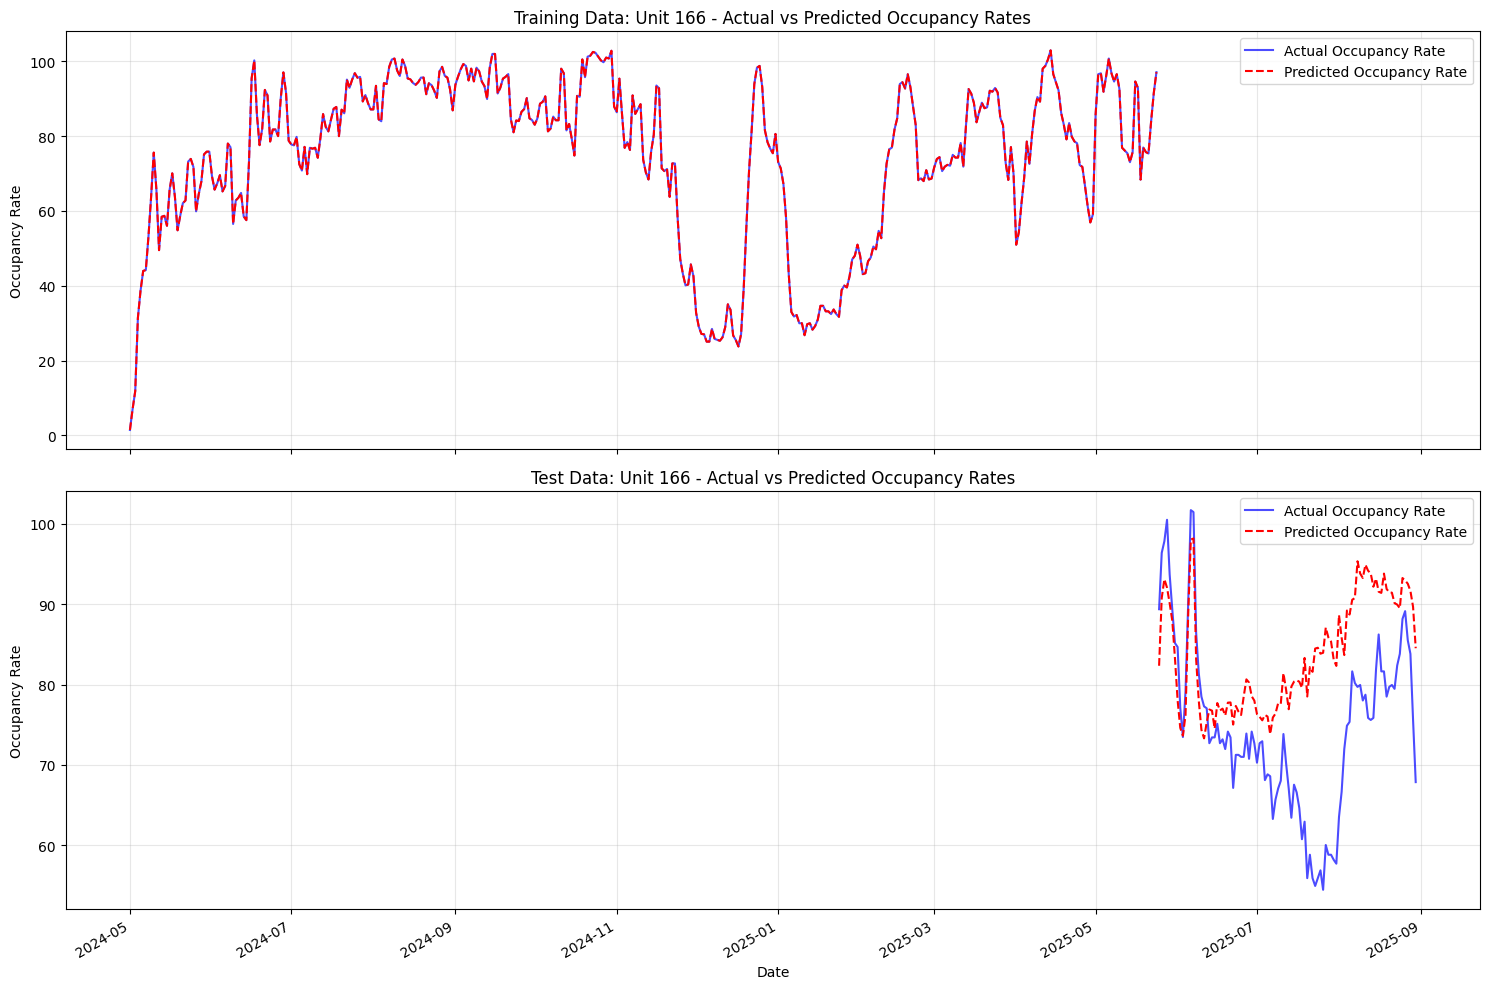

Plotting predictions on the full unit DataFrame...
Columns used for prediction: ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'total_price_166']
Target column: taux_occupation_166


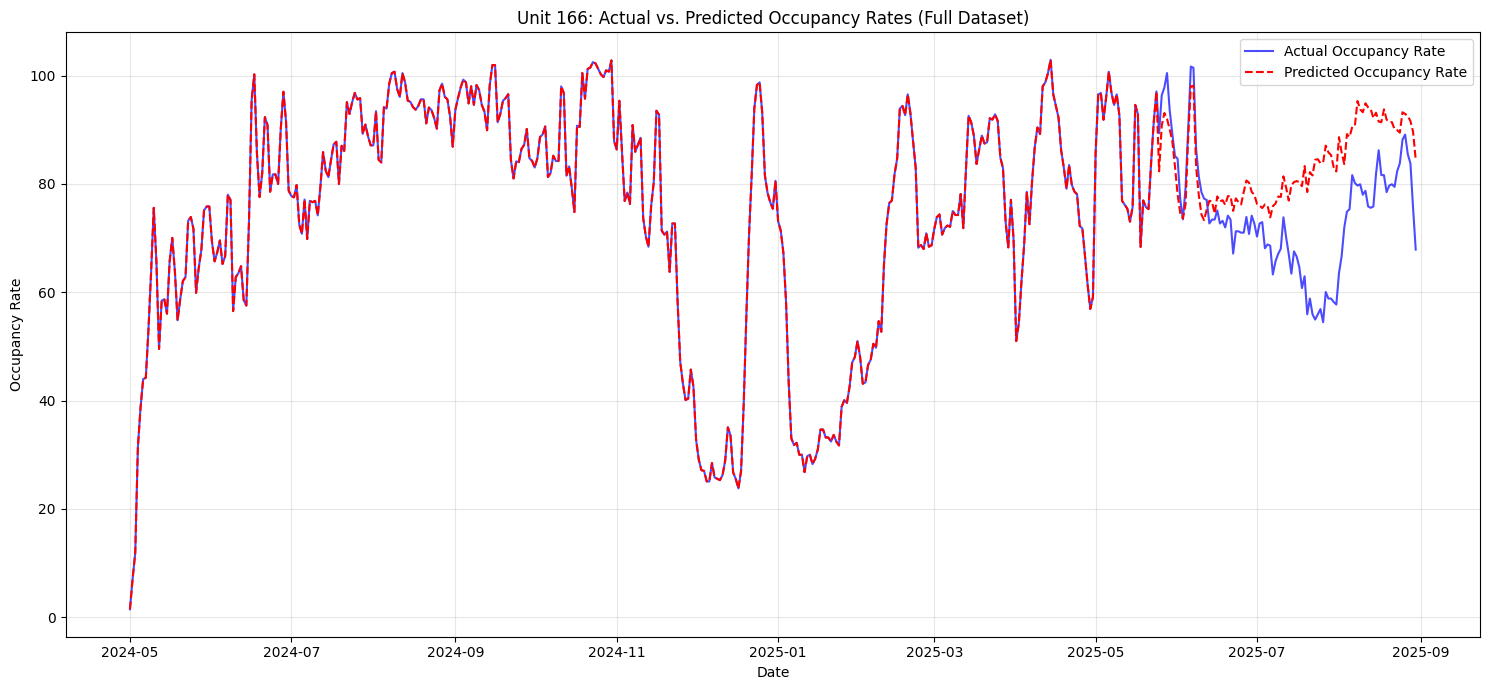


Pipeline finished for Unit 166 (target: taux).
--- End XGBoost Pipeline ---
--- Starting XGBoost Pipeline for Unit 167 ---
Target type: taux

[Step 1/3] Splitting data with test_size=0.2...
Split complete. Test size: 0.20
Target column: taux_occupation_167
Training set range: 2024-05-01 00:00:00 to 2025-05-24 00:00:00 (389 samples)
Testing set range: 2025-05-25 00:00:00 to 2025-08-30 00:00:00 (98 samples)

[Step 2/3] Training and evaluating XGBoost model...

Training XGBoost model for target: taux_occupation_167
Hyperparameters: n_estimators=3000, lr=0.01, max_depth=20
Features used (X): ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'total_price_167']
Training set size: 389 samples
Testing set size: 98 samples

Starting Training...
Training Finished.

Model Evaluation Metrics:
Train RMSE: 0.00
Test RMSE: 17.74
Train MAE: 0.00
Test MAE: 15.20
Train R²: 1.0000
Test R²: 0.2819

Feature Importance:
           Feature  Importance
5  total_price_167    0.347890
2             yea

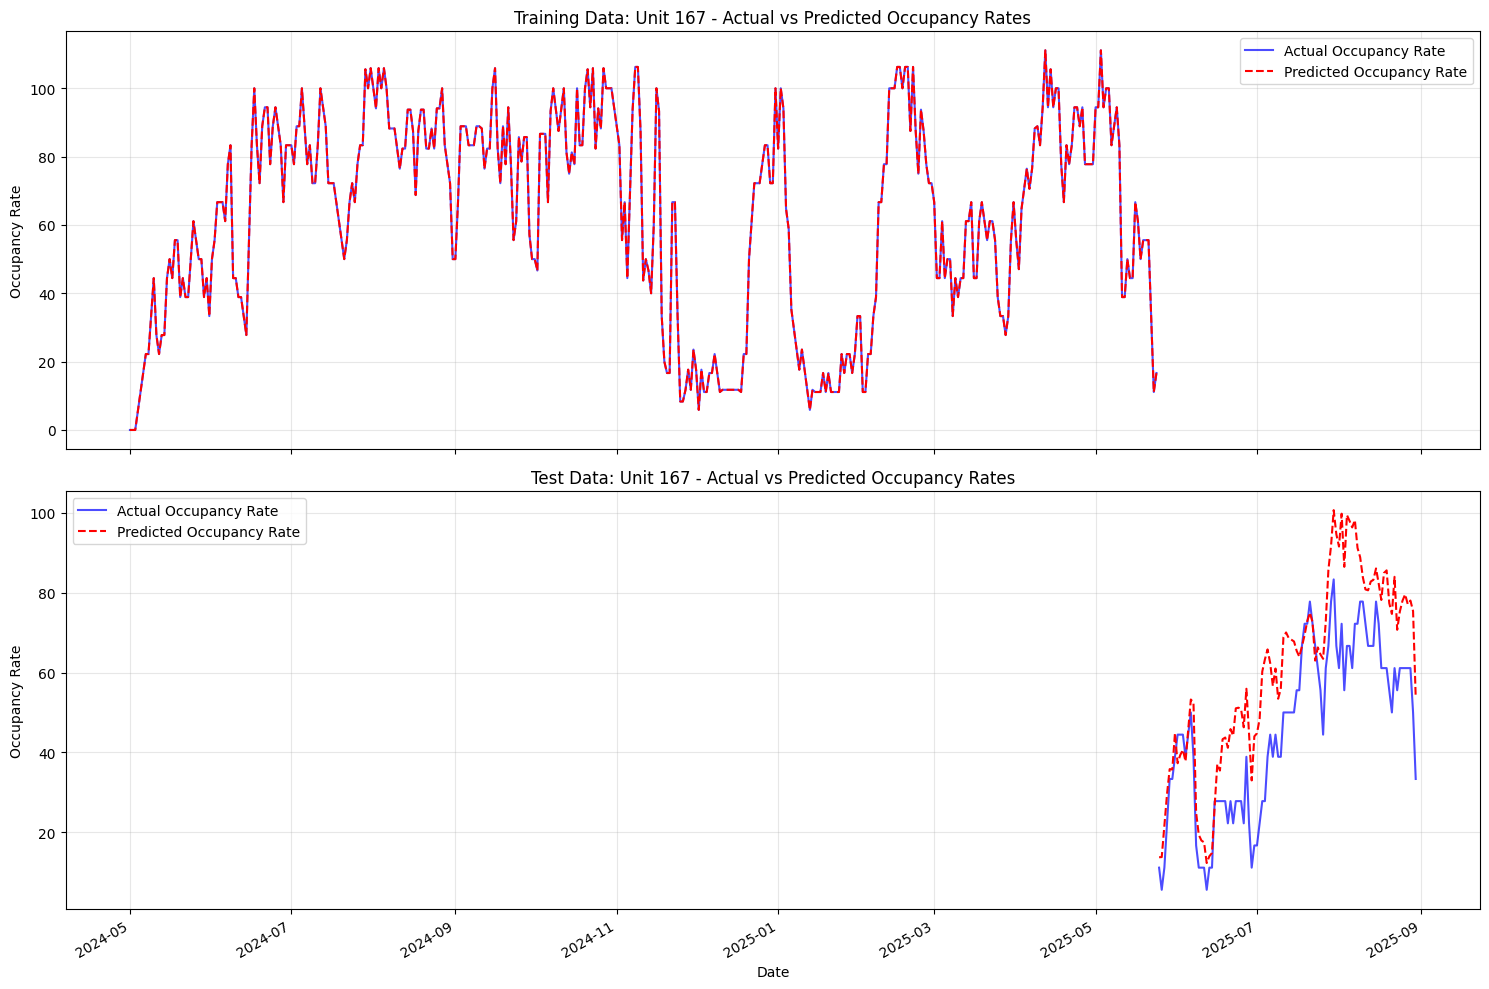

Plotting predictions on the full unit DataFrame...
Columns used for prediction: ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'total_price_167']
Target column: taux_occupation_167


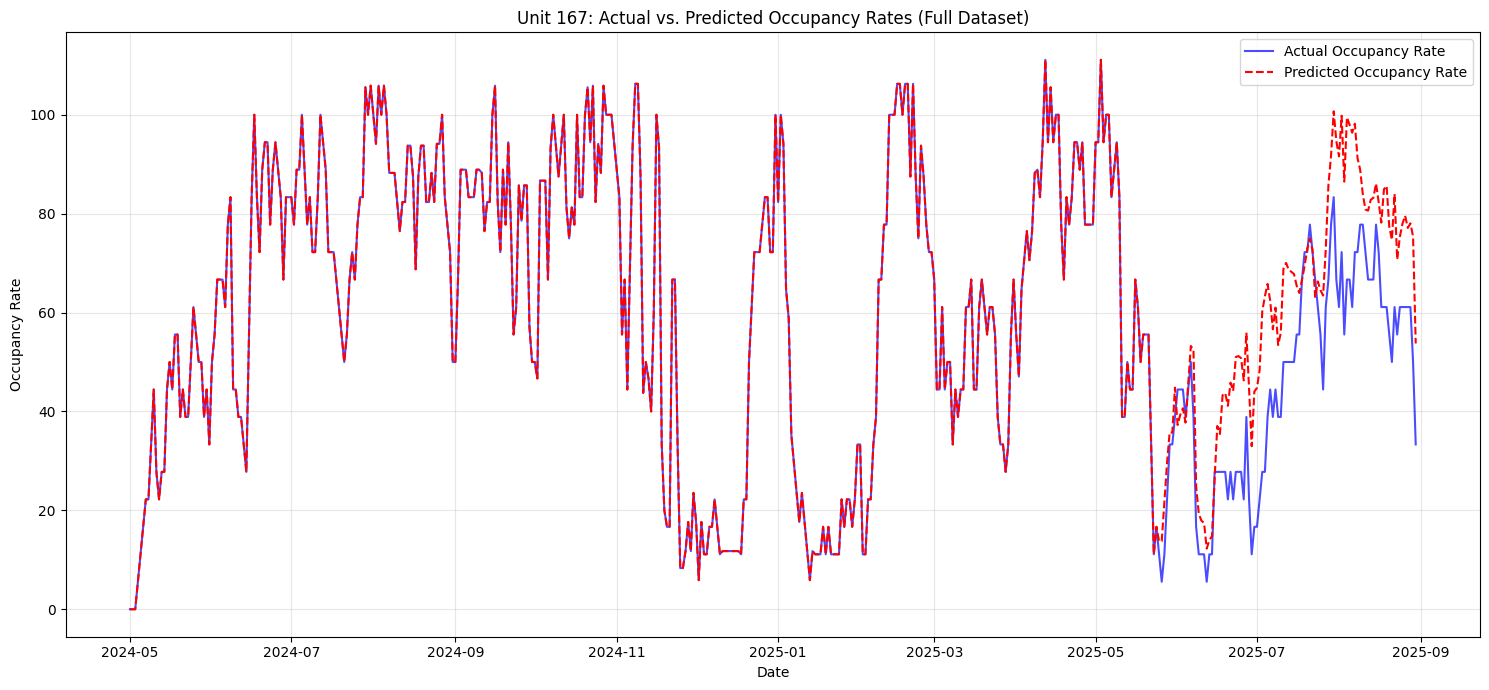


Pipeline finished for Unit 167 (target: taux).
--- End XGBoost Pipeline ---


In [13]:
xgb_results_taux_166 = run_xgboost_pipeline(
    df_166,
    '166',
    test_size=0.2,
    target_type='taux',
    n_estimators=3000,
    max_depth=20,
    learning_rate=0.01,
    subsample=0.8,
    colsample_bytree=0.8,
)

xgb_results_taux_167 = run_xgboost_pipeline(
    df_167,
    '167',
    test_size=0.2,
    target_type='taux',
    n_estimators=3000,
    max_depth=20,
    learning_rate=0.01,
    subsample=0.8,
    colsample_bytree=0.8,
)

In [15]:
save_xgboost_model(
    xgb_results=xgb_results_taux_166,
    folder_path=metadata['XGBoostModelsV2']['taux_166']['folder_path'],
    model_name=metadata['XGBoostModelsV2']['taux_166']['model_name'],
)

save_xgboost_model(
    xgb_results=xgb_results_taux_167,
    folder_path=metadata['XGBoostModelsV2']['taux_167']['folder_path'],
    model_name=metadata['XGBoostModelsV2']['taux_167']['model_name'],
)

Created directory: ../TrainedModels/UnitsBasedModelsV2/PredictTaux/XGBoostModels
Model successfully saved to ../TrainedModels/UnitsBasedModelsV2/PredictTaux/XGBoostModels\xgboost_v2_model_taux_166.pkl
Model successfully saved to ../TrainedModels/UnitsBasedModelsV2/PredictTaux/XGBoostModels\xgboost_v2_model_taux_167.pkl


'../TrainedModels/UnitsBasedModelsV2/PredictTaux/XGBoostModels\\xgboost_v2_model_taux_167.pkl'

--- Starting XGBoost Pipeline for Unit 166 ---
Target type: price

[Step 1/3] Splitting data with test_size=0.2...
Split complete. Test size: 0.20
Target column: total_price_166
Training set range: 2024-05-01 00:00:00 to 2025-05-24 00:00:00 (389 samples)
Testing set range: 2025-05-25 00:00:00 to 2025-08-30 00:00:00 (98 samples)

[Step 2/3] Training and evaluating XGBoost model...

Training XGBoost model for target: total_price_166
Hyperparameters: n_estimators=3000, lr=0.01, max_depth=20
Features used (X): ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'taux_occupation_166']
Training set size: 389 samples
Testing set size: 98 samples

Starting Training...
Training Finished.

Model Evaluation Metrics:
Train RMSE: 3.58
Test RMSE: 84904.51
Train MAE: 1.64
Test MAE: 56986.86
Train R²: 1.0000
Test R²: -0.3727

Feature Importance:
               Feature  Importance
5  taux_occupation_166    0.350356
4           weekofyear    0.259810
3            dayofyear    0.197335
1           

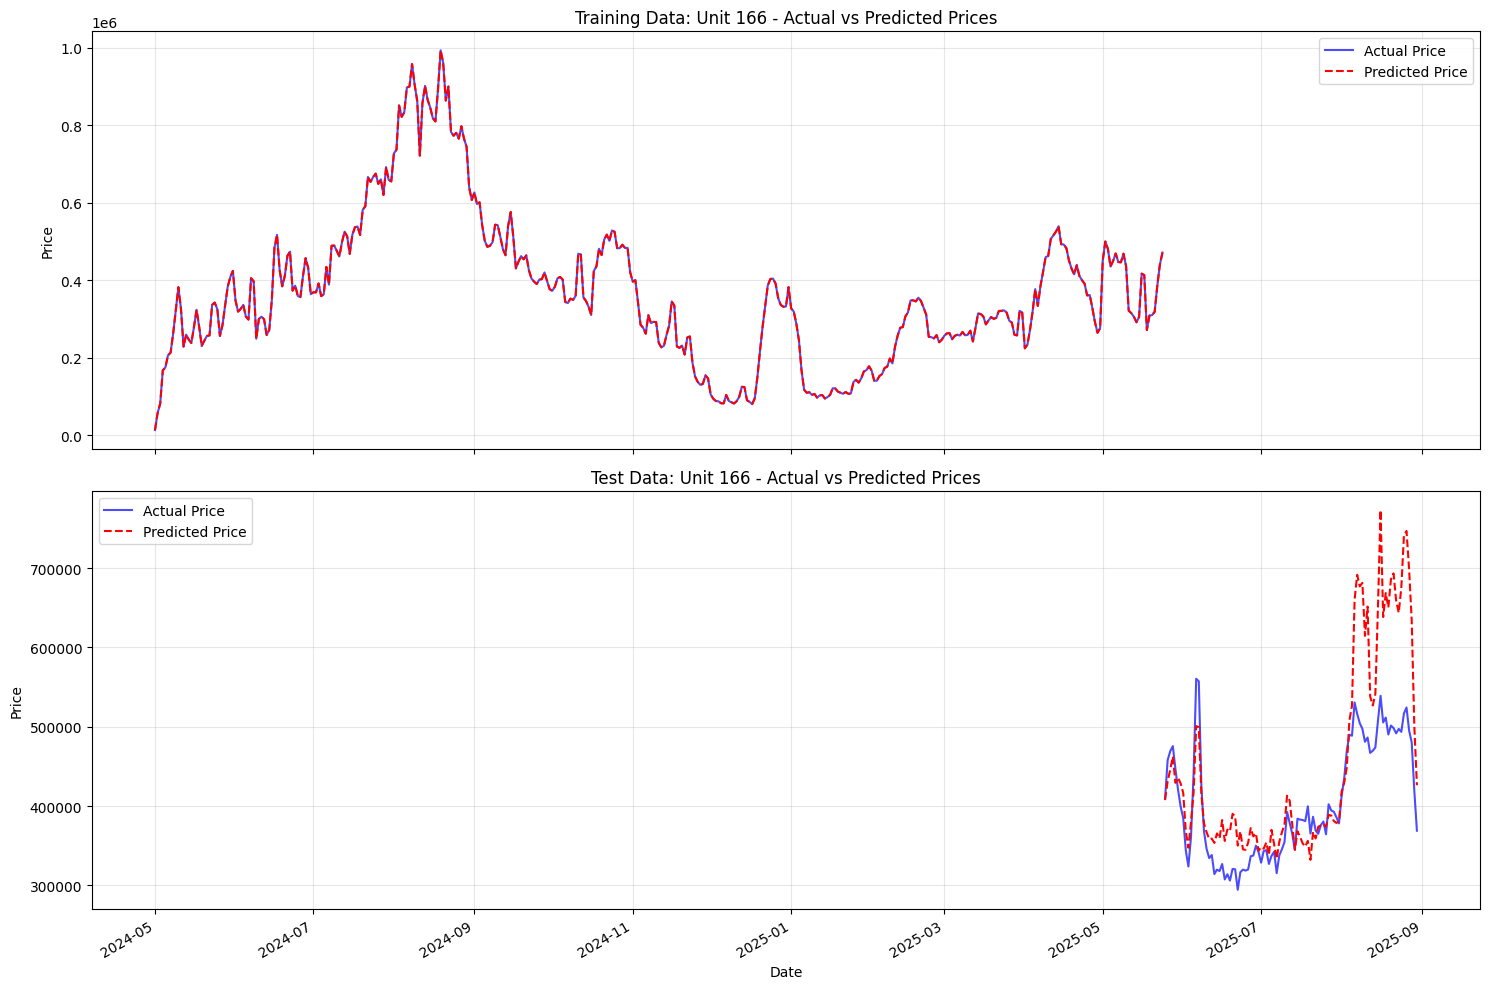

Plotting predictions on the full unit DataFrame...
Columns used for prediction: ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'taux_occupation_166']
Target column: total_price_166


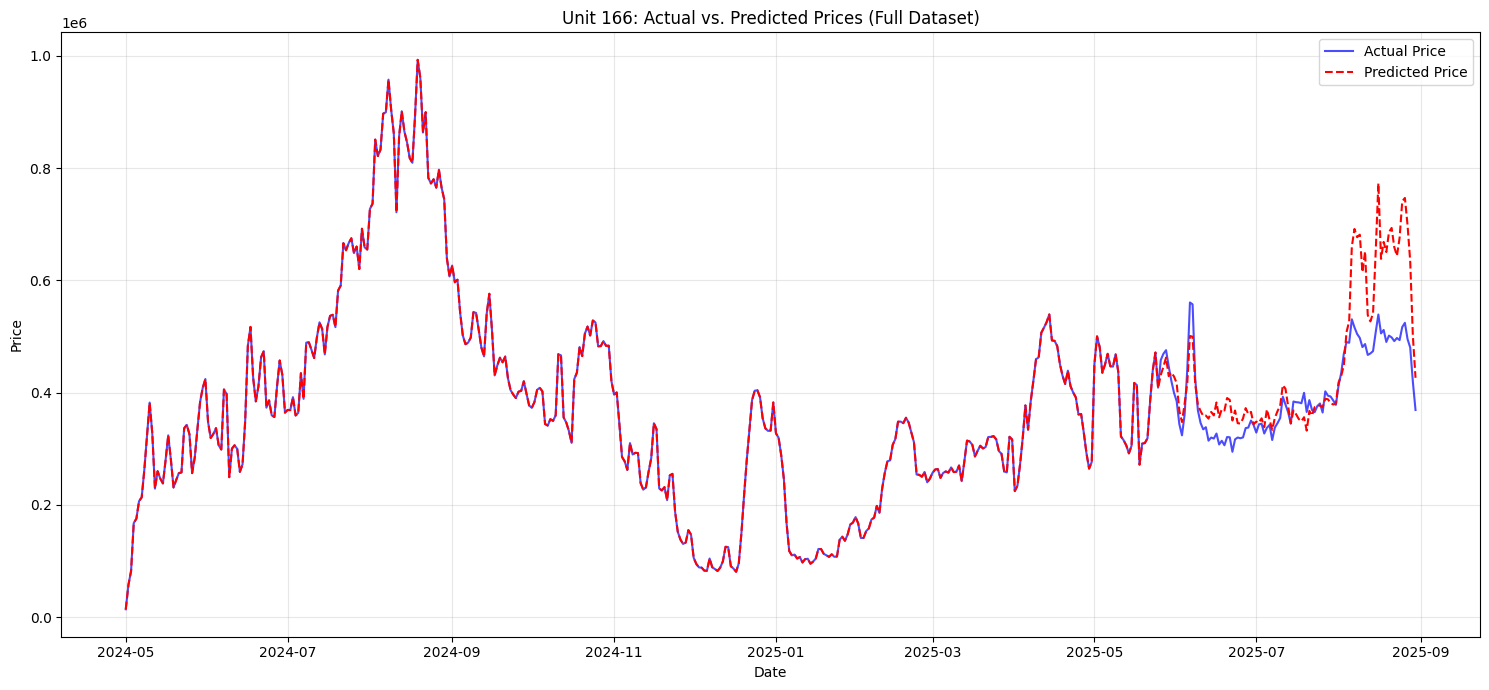


Pipeline finished for Unit 166 (target: price).
--- End XGBoost Pipeline ---
--- Starting XGBoost Pipeline for Unit 167 ---
Target type: price

[Step 1/3] Splitting data with test_size=0.2...
Split complete. Test size: 0.20
Target column: total_price_167
Training set range: 2024-05-01 00:00:00 to 2025-05-24 00:00:00 (389 samples)
Testing set range: 2025-05-25 00:00:00 to 2025-08-30 00:00:00 (98 samples)

[Step 2/3] Training and evaluating XGBoost model...

Training XGBoost model for target: total_price_167
Hyperparameters: n_estimators=3000, lr=0.01, max_depth=20
Features used (X): ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'taux_occupation_167']
Training set size: 389 samples
Testing set size: 98 samples

Starting Training...
Training Finished.

Model Evaluation Metrics:
Train RMSE: 0.31
Test RMSE: 10732.22
Train MAE: 0.16
Test MAE: 7150.95
Train R²: 1.0000
Test R²: -0.2941

Feature Importance:
               Feature  Importance
5  taux_occupation_167    0.443390
4    

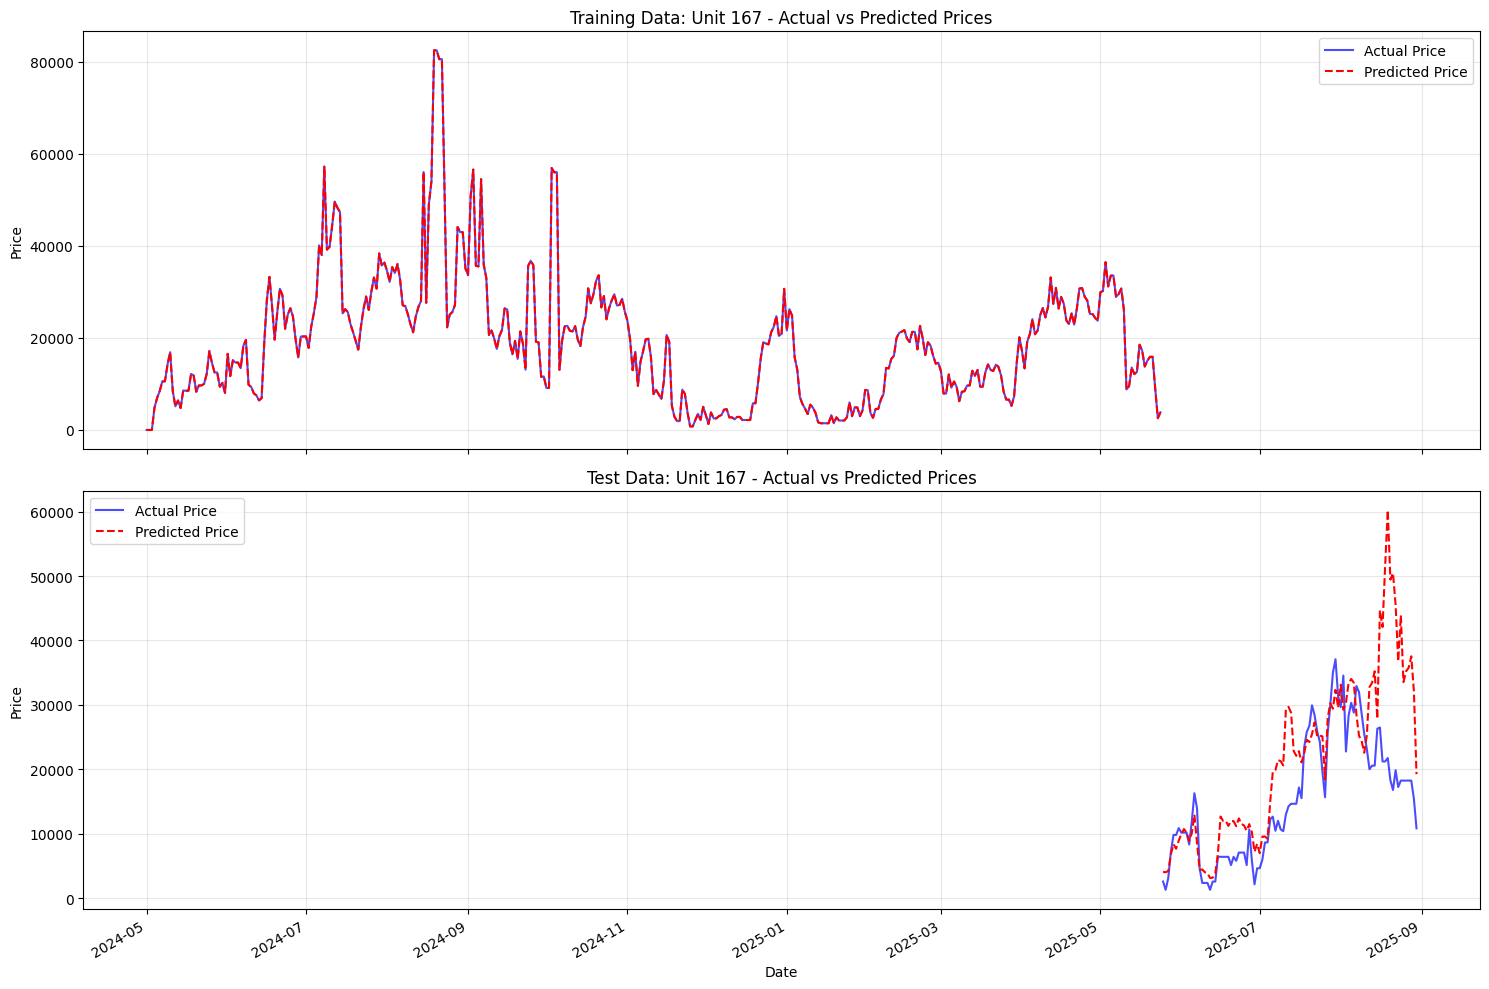

Plotting predictions on the full unit DataFrame...
Columns used for prediction: ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'taux_occupation_167']
Target column: total_price_167


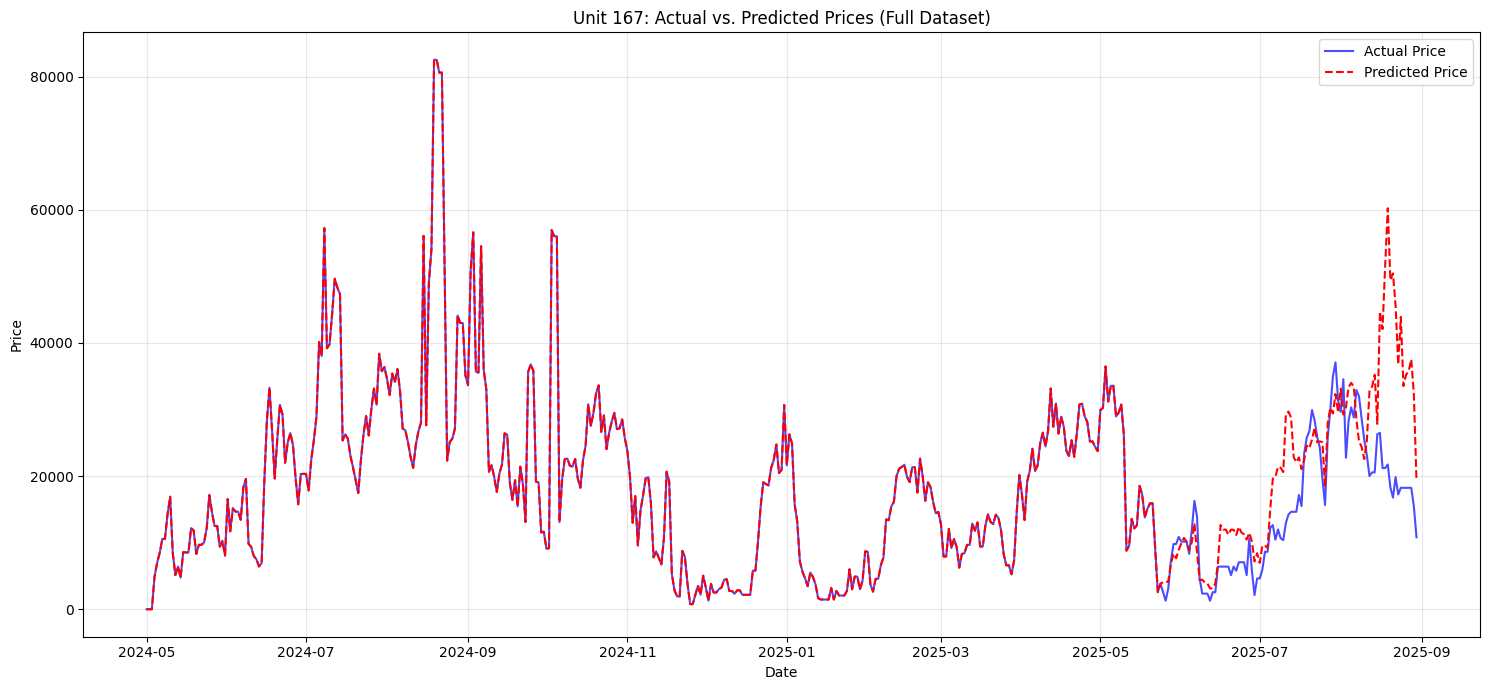


Pipeline finished for Unit 167 (target: price).
--- End XGBoost Pipeline ---


In [16]:
xgb_results_price_166 = run_xgboost_pipeline(
    df_166,
    '166',
    test_size=0.2,
    target_type='price',
    n_estimators=3000,
    max_depth=20,
    learning_rate=0.01,
    subsample=0.8,
    colsample_bytree=0.8,
)

xgb_results_price_167 = run_xgboost_pipeline(
    df_167,
    '167',
    test_size=0.2,
    target_type='price',
    n_estimators=3000,
    max_depth=20,
    learning_rate=0.01,
    subsample=0.8,
    colsample_bytree=0.8,
)

In [17]:
save_xgboost_model(
    xgb_results=xgb_results_price_166,
    folder_path=metadata['XGBoostModelsV2']['price_166']['folder_path'],
    model_name=metadata['XGBoostModelsV2']['price_166']['model_name'],
)

save_xgboost_model(
    xgb_results=xgb_results_price_167,
    folder_path=metadata['XGBoostModelsV2']['price_167']['folder_path'],
    model_name=metadata['XGBoostModelsV2']['price_167']['model_name'],
)

Created directory: ../TrainedModels/UnitsBasedModelsV2/PredictPrice/XGBoostModels
Model successfully saved to ../TrainedModels/UnitsBasedModelsV2/PredictPrice/XGBoostModels\xgboost_v2_model_166.pkl
Model successfully saved to ../TrainedModels/UnitsBasedModelsV2/PredictPrice/XGBoostModels\xgboost_v2_model_167.pkl


'../TrainedModels/UnitsBasedModelsV2/PredictPrice/XGBoostModels\\xgboost_v2_model_167.pkl'

In [18]:
xgboost_results = find_max_price_for_date_range_xgboost(
    start_date_str='2025-04-20',
    end_date_str='2025-04-30',
    unit_id='166',
    min_value=30.0,
    max_value=120.0,
    step=1,
    target_type='price',
    modelsName='XGBoostModelsV2'
)

Loading model for target='price', unit='166'...
Model name: xgboost_v2_model_166
XGBoost model successfully loaded from ../TrainedModels/UnitsBasedModelsV2/PredictPrice/XGBoostModels\xgboost_v2_model_166.pkl
Model loaded successfully.

Searching for optimal taux for XGBoost model (unit 166) on 2025-04-20...
Target: Maximize price
Range: 30.0-120.0, step: 1


Testing XGBoost taux values:   7%|▋         | 6/91 [00:00<00:01, 52.93it/s]


Predicting price with XGBoost for Unit 166 on 2025-04-20
Using taux input value: 30.0
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          6      4  2025        110          16                 30.0
Predicted total_price_166: 217777.11

Predicting price with XGBoost for Unit 166 on 2025-04-20
Using taux input value: 31.0
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          6      4  2025        110          16                 31.0
Predicted total_price_166: 218942.36

Predicting price with XGBoost for Unit 166 on 2025-04-20
Using taux input value: 32.0
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          6      4  2025        110          16                 32.0
Predicted total_price_166: 221606.28

Predicting price with XGBoost for Unit 166 on 2025-04-20
Using taux input value: 33.0
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          6      4  2025        110          16   

Testing XGBoost taux values:  20%|█▉        | 18/91 [00:00<00:01, 52.39it/s]

Predicted total_price_166: 251496.64

Predicting price with XGBoost for Unit 166 on 2025-04-20
Using taux input value: 41.0
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          6      4  2025        110          16                 41.0
Predicted total_price_166: 252204.48

Predicting price with XGBoost for Unit 166 on 2025-04-20
Using taux input value: 42.0
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          6      4  2025        110          16                 42.0
Predicted total_price_166: 252204.48

Predicting price with XGBoost for Unit 166 on 2025-04-20
Using taux input value: 43.0
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          6      4  2025        110          16                 43.0
Predicted total_price_166: 253535.73

Predicting price with XGBoost for Unit 166 on 2025-04-20
Using taux input value: 44.0
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          6  

...

Predicted total_price_166: 415190.91

Predicting price with XGBoost for Unit 166 on 2025-04-30
Using taux input value: 93.0
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          2      4  2025        120          18                 93.0
Predicted total_price_166: 406951.53

Predicting price with XGBoost for Unit 166 on 2025-04-30
Using taux input value: 94.0
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          2      4  2025        120          18                 94.0
Predicted total_price_166: 426618.75

Predicting price with XGBoost for Unit 166 on 2025-04-30
Using taux input value: 95.0
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          2      4  2025        120          18                 95.0
Predicted total_price_166: 435382.31

Predicting price with XGBoost for Unit 166 on 2025-04-30
Using taux input value: 96.0
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          2  

Testing XGBoost taux values:  91%|█████████ | 83/91 [00:01<00:00, 52.75it/s]

Predicted total_price_166: 460044.03

Predicting price with XGBoost for Unit 166 on 2025-04-30
Using taux input value: 106.0
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          2      4  2025        120          18                106.0
Predicted total_price_166: 460044.03

Predicting price with XGBoost for Unit 166 on 2025-04-30
Using taux input value: 107.0
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          2      4  2025        120          18                107.0
Predicted total_price_166: 460044.03

Predicting price with XGBoost for Unit 166 on 2025-04-30
Using taux input value: 108.0
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          2      4  2025        120          18                108.0
Predicted total_price_166: 460044.03

Predicting price with XGBoost for Unit 166 on 2025-04-30
Using taux input value: 109.0
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0         

Testing XGBoost taux values: 100%|██████████| 91/91 [00:01<00:00, 51.33it/s]

Predicted total_price_166: 460044.03

Predicting price with XGBoost for Unit 166 on 2025-04-30
Using taux input value: 119.0
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          2      4  2025        120          18                119.0
Predicted total_price_166: 460044.03

Predicting price with XGBoost for Unit 166 on 2025-04-30
Using taux input value: 120.0
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          2      4  2025        120          18                120.0
Predicted total_price_166: 460044.03

XGBoost Search complete. Optimal taux_occupation: 103.00 -> 
Max Price: 460044.03


In [19]:
xgboost_results

{'2025-04-20': {'best_input': 103.0, 'max_output': 506712.8125},
 '2025-04-21': {'best_input': 103.0, 'max_output': 512016.84375},
 '2025-04-22': {'best_input': 103.0, 'max_output': 493079.90625},
 '2025-04-23': {'best_input': 103.0, 'max_output': 489889.03125},
 '2025-04-24': {'best_input': 103.0, 'max_output': 496136.09375},
 '2025-04-25': {'best_input': 103.0, 'max_output': 486159.25},
 '2025-04-26': {'best_input': 103.0, 'max_output': 484668.0},
 '2025-04-27': {'best_input': 103.0, 'max_output': 478934.65625},
 '2025-04-28': {'best_input': 103.0, 'max_output': 467313.0},
 '2025-04-29': {'best_input': 103.0, 'max_output': 454510.59375},
 '2025-04-30': {'best_input': 103.0, 'max_output': 460044.03125}}

In [20]:
xgboost_results = find_max_price_for_date_range_xgboost(
    start_date_str='2025-04-20',
    end_date_str='2025-04-30',
    unit_id='166',
    min_value=30.0,
    max_value=100.0,
    step=1,
    target_type='price',
    modelsName='XGBoostModelsV2'
)

Loading model for target='price', unit='166'...
Model name: xgboost_v2_model_166
XGBoost model successfully loaded from ../TrainedModels/UnitsBasedModelsV2/PredictPrice/XGBoostModels\xgboost_v2_model_166.pkl
Model loaded successfully.

Searching for optimal taux for XGBoost model (unit 166) on 2025-04-20...
Target: Maximize price
Range: 30.0-100.0, step: 1


Testing XGBoost taux values:   8%|▊         | 6/71 [00:00<00:01, 57.69it/s]


Predicting price with XGBoost for Unit 166 on 2025-04-20
Using taux input value: 30.0
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          6      4  2025        110          16                 30.0
Predicted total_price_166: 217777.11

Predicting price with XGBoost for Unit 166 on 2025-04-20
Using taux input value: 31.0
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          6      4  2025        110          16                 31.0
Predicted total_price_166: 218942.36

Predicting price with XGBoost for Unit 166 on 2025-04-20
Using taux input value: 32.0
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          6      4  2025        110          16                 32.0
Predicted total_price_166: 221606.28

Predicting price with XGBoost for Unit 166 on 2025-04-20
Using taux input value: 33.0
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          6      4  2025        110          16   

Testing XGBoost taux values:  25%|██▌       | 18/71 [00:00<00:00, 54.77it/s]

Predicted total_price_166: 252204.48

Predicting price with XGBoost for Unit 166 on 2025-04-20
Using taux input value: 42.0
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          6      4  2025        110          16                 42.0
Predicted total_price_166: 252204.48

Predicting price with XGBoost for Unit 166 on 2025-04-20
Using taux input value: 43.0
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          6      4  2025        110          16                 43.0
Predicted total_price_166: 253535.73

Predicting price with XGBoost for Unit 166 on 2025-04-20
Using taux input value: 44.0
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          6      4  2025        110          16                 44.0
Predicted total_price_166: 263255.84

Predicting price with XGBoost for Unit 166 on 2025-04-20
Using taux input value: 45.0
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          6  

...

Predicted total_price_166: 327829.41

Predicting price with XGBoost for Unit 166 on 2025-04-30
Using taux input value: 77.0
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          2      4  2025        120          18                 77.0
Predicted total_price_166: 329995.22

Predicting price with XGBoost for Unit 166 on 2025-04-30
Using taux input value: 78.0
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          2      4  2025        120          18                 78.0
Predicted total_price_166: 355308.84

Predicting price with XGBoost for Unit 166 on 2025-04-30
Using taux input value: 79.0
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          2      4  2025        120          18                 79.0
Predicted total_price_166: 366092.31

Predicting price with XGBoost for Unit 166 on 2025-04-30
Using taux input value: 80.0
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          2  

Testing XGBoost taux values:  93%|█████████▎| 66/71 [00:01<00:00, 54.31it/s]


Predicting price with XGBoost for Unit 166 on 2025-04-30
Using taux input value: 88.0
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          2      4  2025        120          18                 88.0
Predicted total_price_166: 403699.50

Predicting price with XGBoost for Unit 166 on 2025-04-30
Using taux input value: 89.0
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          2      4  2025        120          18                 89.0
Predicted total_price_166: 403399.50

Predicting price with XGBoost for Unit 166 on 2025-04-30
Using taux input value: 90.0
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          2      4  2025        120          18                 90.0
Predicted total_price_166: 405236.56

Predicting price with XGBoost for Unit 166 on 2025-04-30
Using taux input value: 91.0
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          2      4  2025        120          18   

Testing XGBoost taux values: 100%|██████████| 71/71 [00:01<00:00, 54.13it/s]

Predicted total_price_166: 448484.00

Predicting price with XGBoost for Unit 166 on 2025-04-30
Using taux input value: 100.0
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          2      4  2025        120          18                100.0
Predicted total_price_166: 452965.31

XGBoost Search complete. Optimal taux_occupation: 100.00 -> 
Max Price: 452965.31


In [21]:
xgboost_results

{'2025-04-20': {'best_input': 100.0, 'max_output': 497615.0},
 '2025-04-21': {'best_input': 100.0, 'max_output': 505984.25},
 '2025-04-22': {'best_input': 100.0, 'max_output': 487984.15625},
 '2025-04-23': {'best_input': 100.0, 'max_output': 482784.0625},
 '2025-04-24': {'best_input': 100.0, 'max_output': 486930.65625},
 '2025-04-25': {'best_input': 100.0, 'max_output': 478158.1875},
 '2025-04-26': {'best_input': 100.0, 'max_output': 476999.03125},
 '2025-04-27': {'best_input': 100.0, 'max_output': 469876.28125},
 '2025-04-28': {'best_input': 100.0, 'max_output': 461304.40625},
 '2025-04-29': {'best_input': 100.0, 'max_output': 449440.96875},
 '2025-04-30': {'best_input': 100.0, 'max_output': 452965.3125}}

### Train the LSTM models on the **new data**

--- Starting LSTM Pipeline for Unit 166 (predicting Occupancy Rate) ---

[Step 1/4] Splitting data with test_size=0.2...
Split complete. Test size: 0.20
Target column: taux_occupation_166
Training set range: 2024-05-01 00:00:00 to 2025-05-24 00:00:00 (389 samples)
Testing set range: 2025-05-25 00:00:00 to 2025-08-30 00:00:00 (98 samples)

[Step 2/4] Training and evaluating LSTM model...

Training LSTM model for target: taux_occupation_166 (predicting Occupancy Rate)
Hyperparameters: seq_len=10, batch=16, epochs=80, lr=0.001
Features used (X): ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'total_price_166']

Starting Training...


Epoch 1/80:   0%|          | 0/24 [00:00<?, ?it/s]

Epoch [10/80], Loss: 0.060337


Epoch [20/80], Loss: 0.051766


Epoch [30/80], Loss: 0.029874


Epoch [40/80], Loss: 0.023127


Epoch [50/80], Loss: 0.017787


Epoch [60/80], Loss: 0.015262


Epoch [70/80], Loss: 0.013516


Epoch [80/80], Loss: 0.012612
Training Finished.

Model Evaluation Metrics for Occupancy Rate prediction:
Train RMSE: 9.25
Test RMSE: 18.61
Train MAE: 7.52
Test MAE: 16.62
Train R²: 0.8061
Test R²: -2.7278

[Step 3/4] Plotting results...
Plotting training loss...


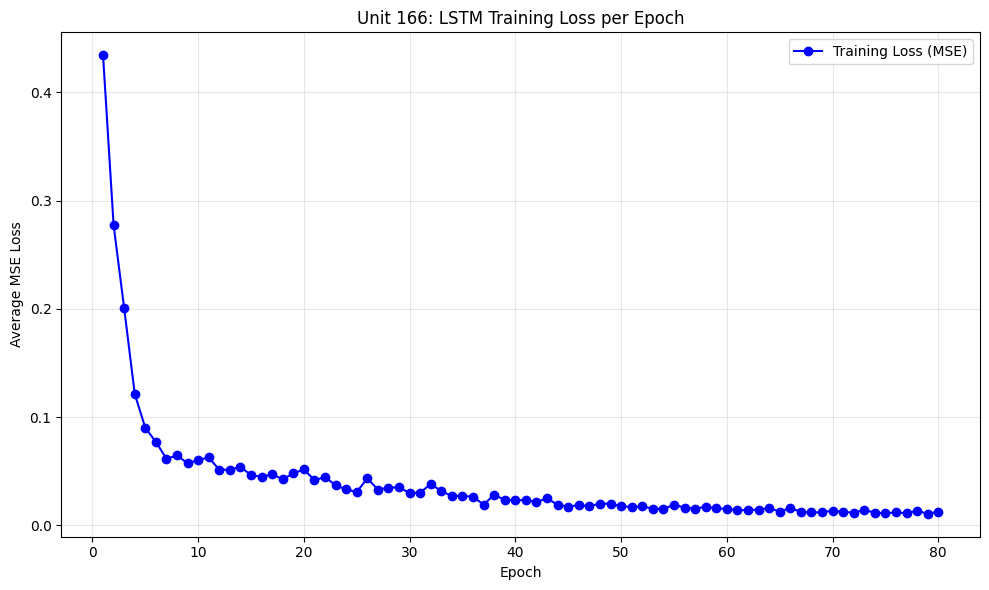

Plotting predictions on train/test split...


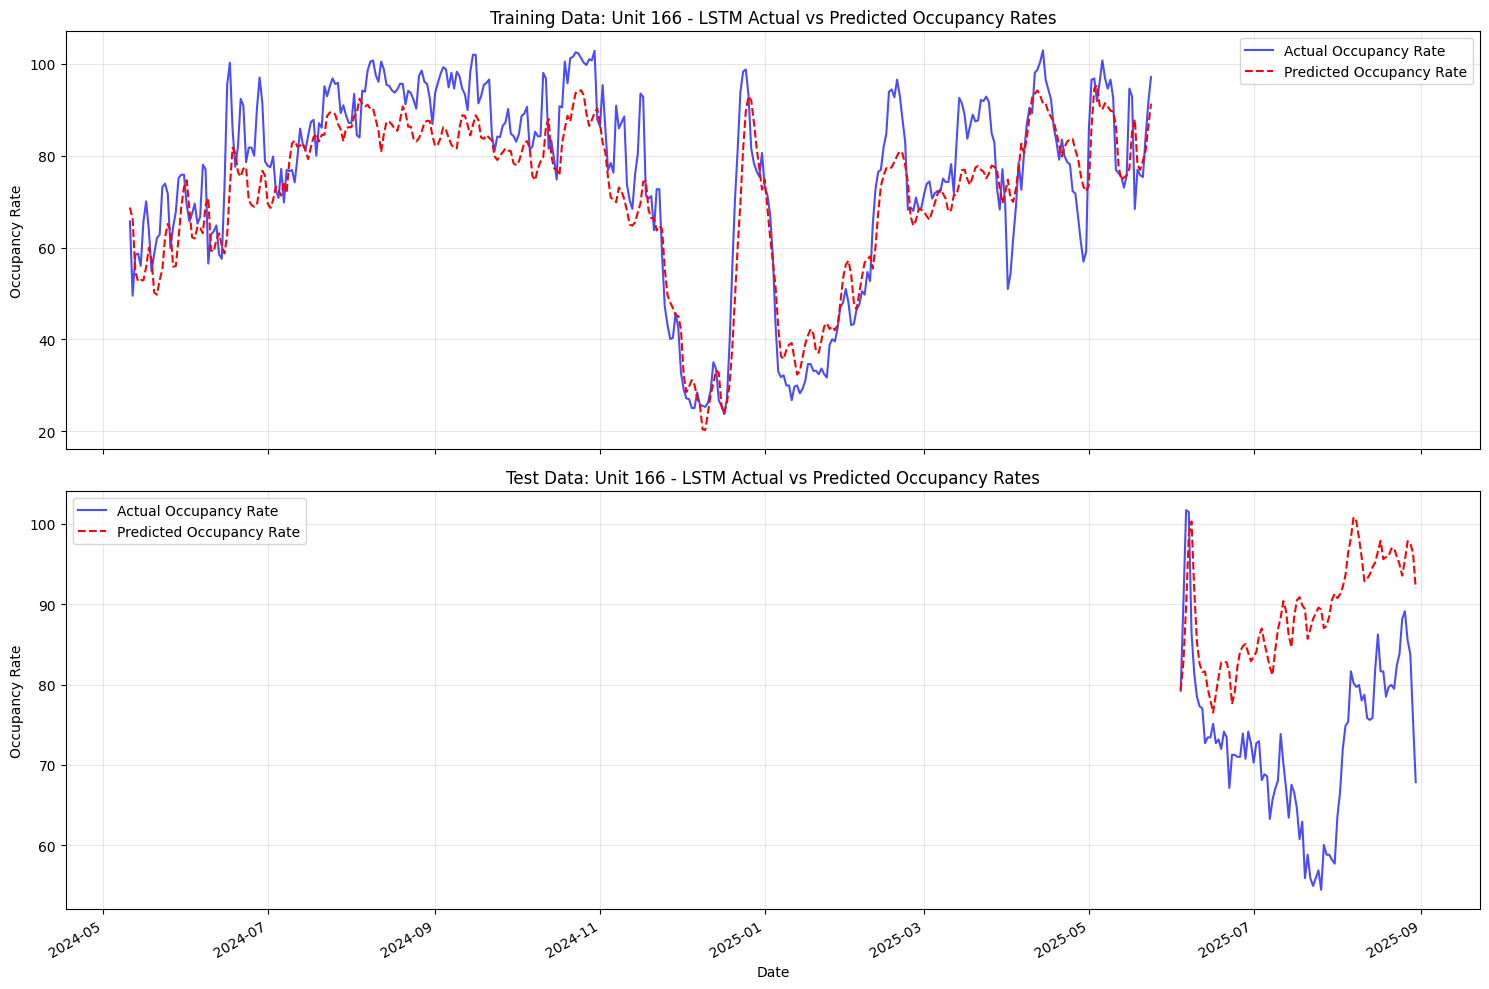

Plotting predictions on the full unit DataFrame...


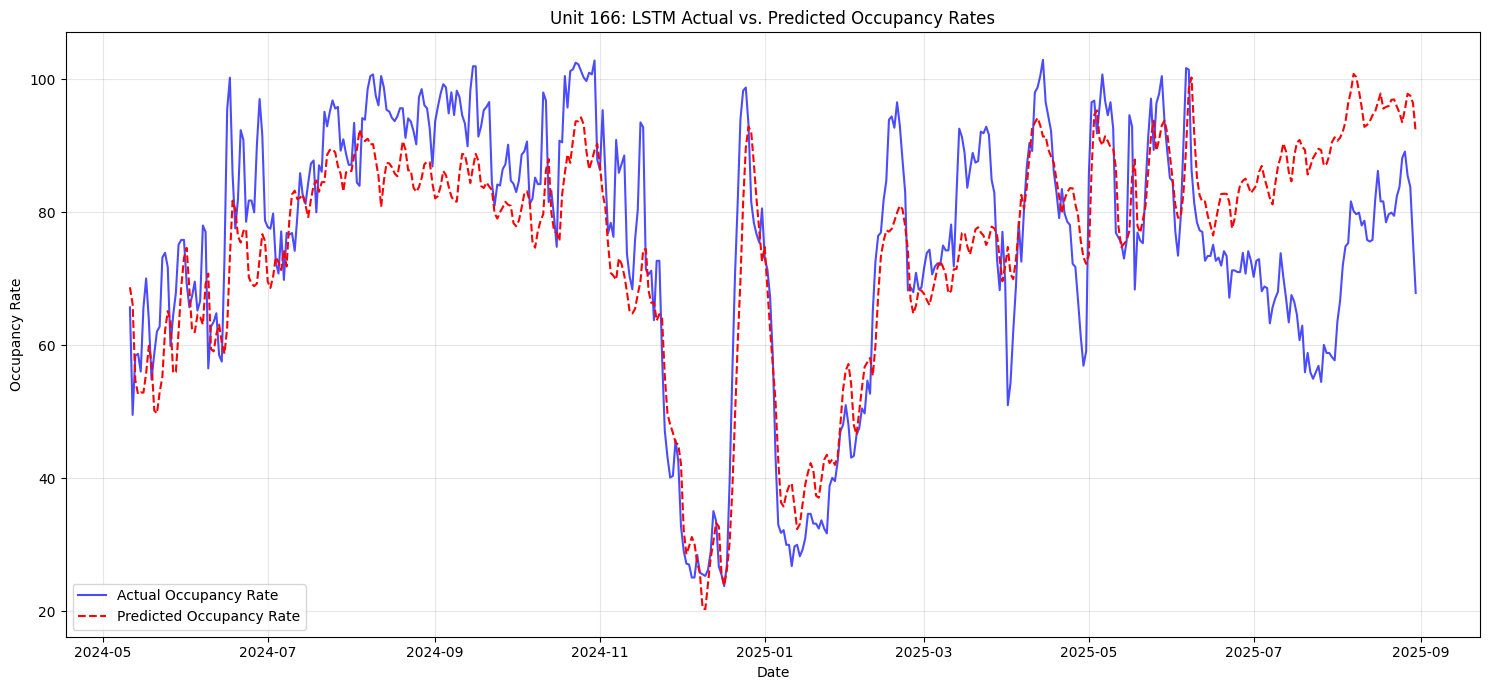


[Step 4/4] Pipeline finished for Unit 166.
--- End LSTM Pipeline ---
--- Starting LSTM Pipeline for Unit 167 (predicting Occupancy Rate) ---

[Step 1/4] Splitting data with test_size=0.2...
Split complete. Test size: 0.20
Target column: taux_occupation_167
Training set range: 2024-05-01 00:00:00 to 2025-05-24 00:00:00 (389 samples)
Testing set range: 2025-05-25 00:00:00 to 2025-08-30 00:00:00 (98 samples)

[Step 2/4] Training and evaluating LSTM model...

Training LSTM model for target: taux_occupation_167 (predicting Occupancy Rate)
Hyperparameters: seq_len=10, batch=16, epochs=80, lr=0.001
Features used (X): ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'total_price_167']

Starting Training...


Epoch [10/80], Loss: 0.065442


Epoch [20/80], Loss: 0.042014


Epoch [30/80], Loss: 0.033454


Epoch [40/80], Loss: 0.030947


Epoch [50/80], Loss: 0.032123


Epoch [60/80], Loss: 0.024835


Epoch [70/80], Loss: 0.024686


Epoch [80/80], Loss: 0.024631
Training Finished.

Model Evaluation Metrics for Occupancy Rate prediction:
Train RMSE: 14.37
Test RMSE: 14.15
Train MAE: 11.22
Test MAE: 11.16
Train R²: 0.7552
Test R²: 0.5323

[Step 3/4] Plotting results...
Plotting training loss...


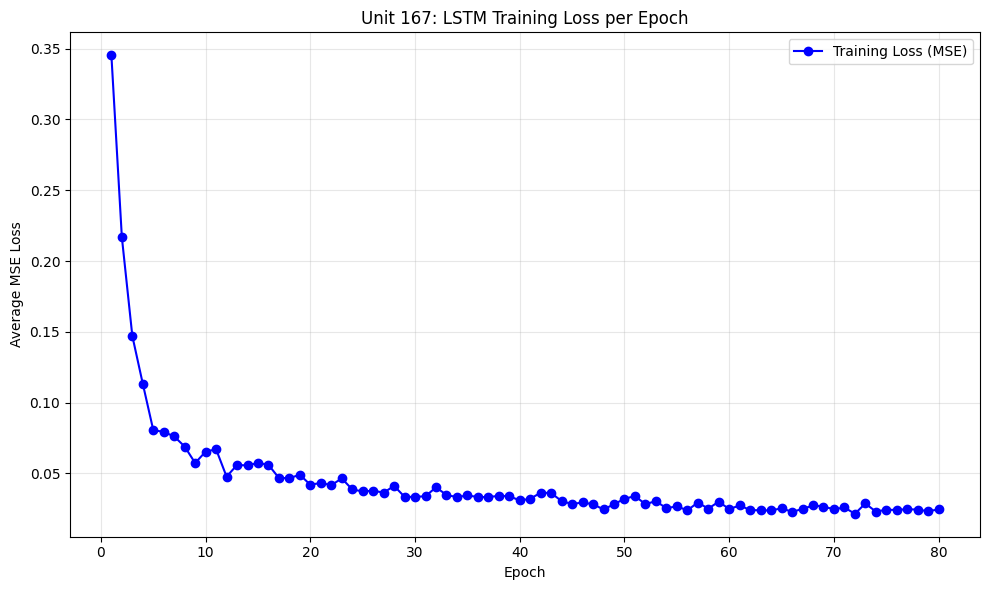

Plotting predictions on train/test split...


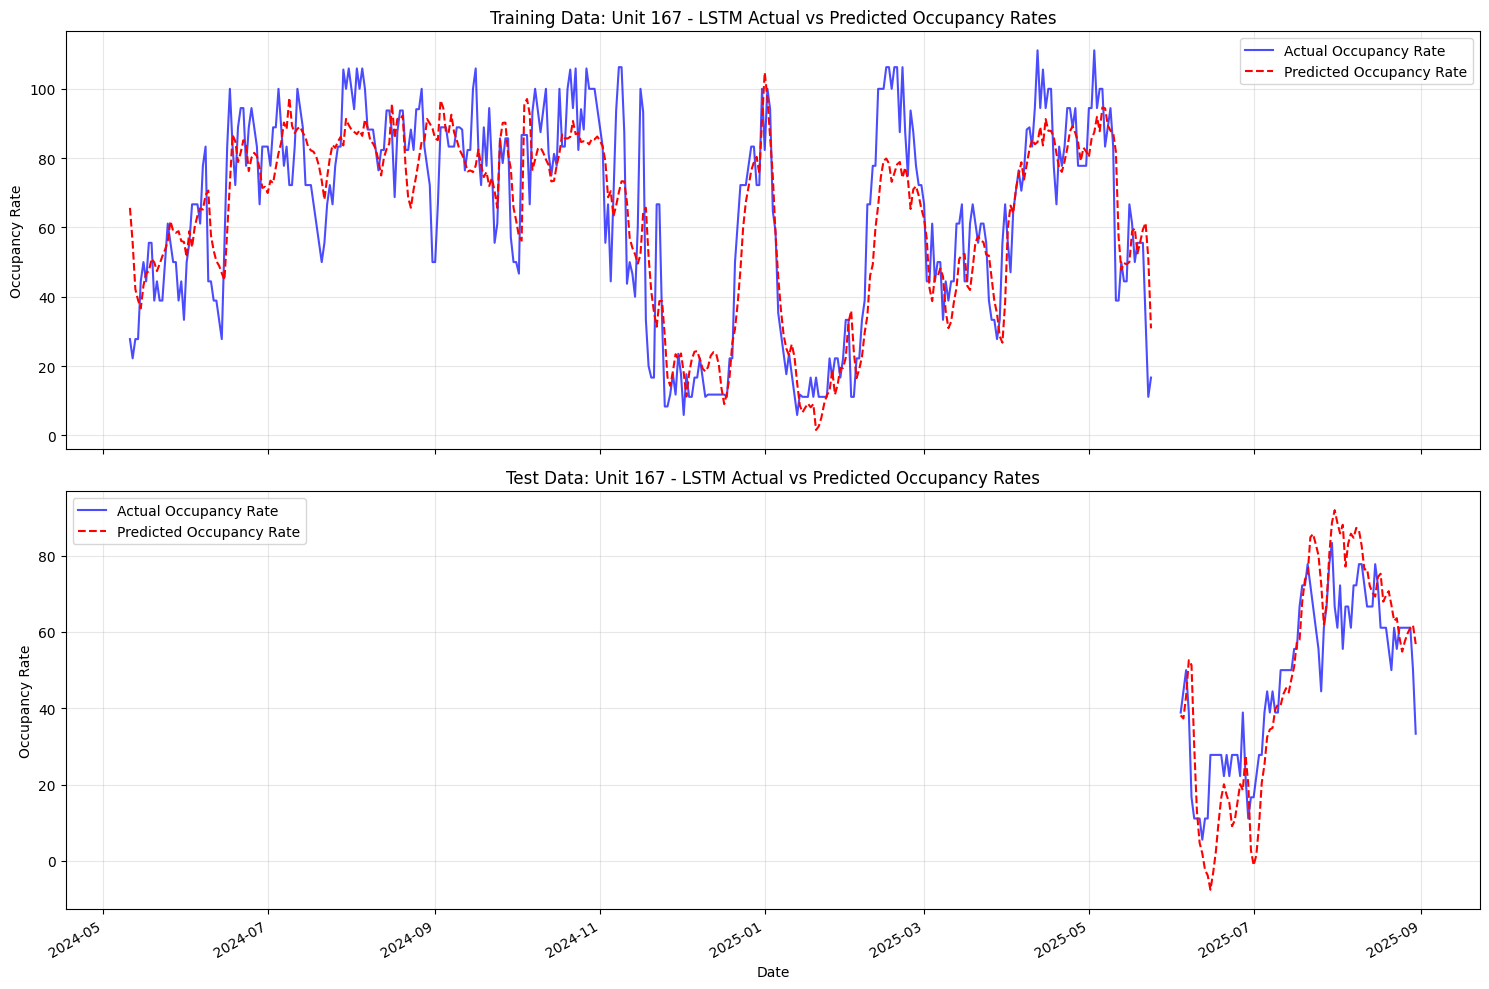

Plotting predictions on the full unit DataFrame...


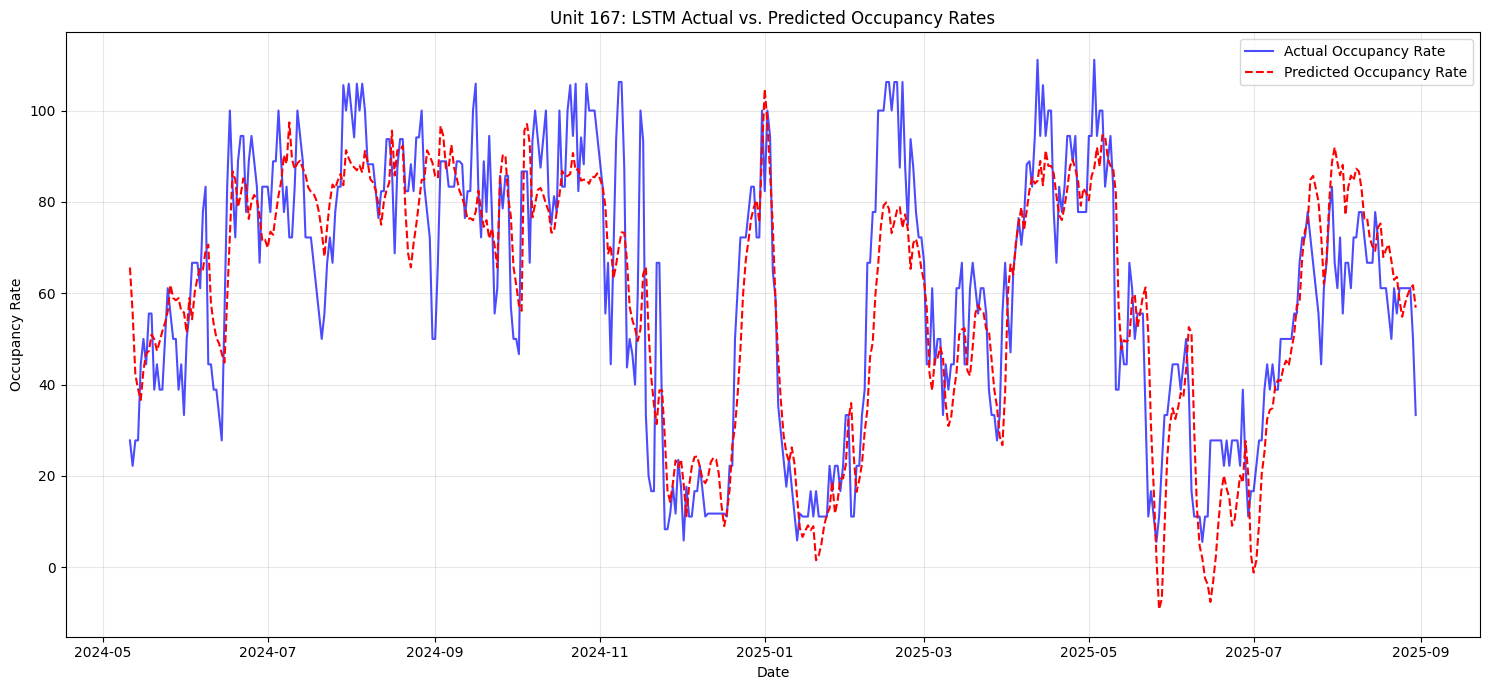


[Step 4/4] Pipeline finished for Unit 167.
--- End LSTM Pipeline ---


In [23]:
lstm_results_taux_166 = run_lstm_pipeline(
    df_166,
    '166',
    test_size=0.2,
    sequence_length=10, 
    epochs=80,
    target_type='taux'
)

lstm_results_taux_167 = run_lstm_pipeline(
    df_167,
    '167',
    test_size=0.2,
    sequence_length=10, 
    epochs=80,
    target_type='taux'
)

In [24]:
save_lstm_model(
    lstm_results=lstm_results_taux_166,
    folder_path=metadata['LSTMModelsV2']['taux_166']['folder_path'],
    model_name=metadata['LSTMModelsV2']['taux_166']['model_name'],
)

save_lstm_model(
    lstm_results=lstm_results_taux_167,
    folder_path=metadata['LSTMModelsV2']['taux_167']['folder_path'],
    model_name=metadata['LSTMModelsV2']['taux_167']['model_name'],
)

Created directory: ../TrainedModels/UnitsBasedModelsV2/PredictTaux/LSTMModels
Model state dictionary successfully saved to ../TrainedModels/UnitsBasedModelsV2/PredictTaux/LSTMModels\lstm_v2_model_166_taux_model_state_dict.pth
Feature scaler successfully saved to ../TrainedModels/UnitsBasedModelsV2/PredictTaux/LSTMModels\lstm_v2_model_166_taux_feature_scaler.pkl
Target scaler successfully saved to ../TrainedModels/UnitsBasedModelsV2/PredictTaux/LSTMModels\lstm_v2_model_166_taux_target_scaler.pkl
Model metadata saved to ../TrainedModels/UnitsBasedModelsV2/PredictTaux/LSTMModels\lstm_v2_model_166_taux_metadata.json
Model state dictionary successfully saved to ../TrainedModels/UnitsBasedModelsV2/PredictTaux/LSTMModels\lstm_v2_model_167_taux_model_state_dict.pth
Feature scaler successfully saved to ../TrainedModels/UnitsBasedModelsV2/PredictTaux/LSTMModels\lstm_v2_model_167_taux_feature_scaler.pkl
Target scaler successfully saved to ../TrainedModels/UnitsBasedModelsV2/PredictTaux/LSTMModels

{'model_state_dict': '../TrainedModels/UnitsBasedModelsV2/PredictTaux/LSTMModels\\lstm_v2_model_167_taux_model_state_dict.pth',
 'feature_scaler': '../TrainedModels/UnitsBasedModelsV2/PredictTaux/LSTMModels\\lstm_v2_model_167_taux_feature_scaler.pkl',
 'target_scaler': '../TrainedModels/UnitsBasedModelsV2/PredictTaux/LSTMModels\\lstm_v2_model_167_taux_target_scaler.pkl',
 'metadata': '../TrainedModels/UnitsBasedModelsV2/PredictTaux/LSTMModels\\lstm_v2_model_167_taux_metadata.json'}

--- Starting LSTM Pipeline for Unit 166 (predicting Price) ---

[Step 1/4] Splitting data with test_size=0.2...
Split complete. Test size: 0.20
Target column: total_price_166
Training set range: 2024-05-01 00:00:00 to 2025-05-24 00:00:00 (389 samples)
Testing set range: 2025-05-25 00:00:00 to 2025-08-30 00:00:00 (98 samples)

[Step 2/4] Training and evaluating LSTM model...

Training LSTM model for target: total_price_166 (predicting Price)
Hyperparameters: seq_len=10, batch=16, epochs=80, lr=0.001
Features used (X): ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'taux_occupation_166']

Starting Training...


Epoch [10/80], Loss: 0.040202


Epoch [20/80], Loss: 0.031371


Epoch [30/80], Loss: 0.022804


Epoch [40/80], Loss: 0.017007


Epoch [50/80], Loss: 0.014757


Epoch [60/80], Loss: 0.013242


Epoch [70/80], Loss: 0.010920


Epoch [80/80], Loss: 0.011802
Training Finished.

Model Evaluation Metrics for Price prediction:
Train RMSE: 103027.65
Test RMSE: 140320.50
Train MAE: 73096.24
Test MAE: 111188.23
Train R²: 0.7077
Test R²: -2.5388

[Step 3/4] Plotting results...
Plotting training loss...


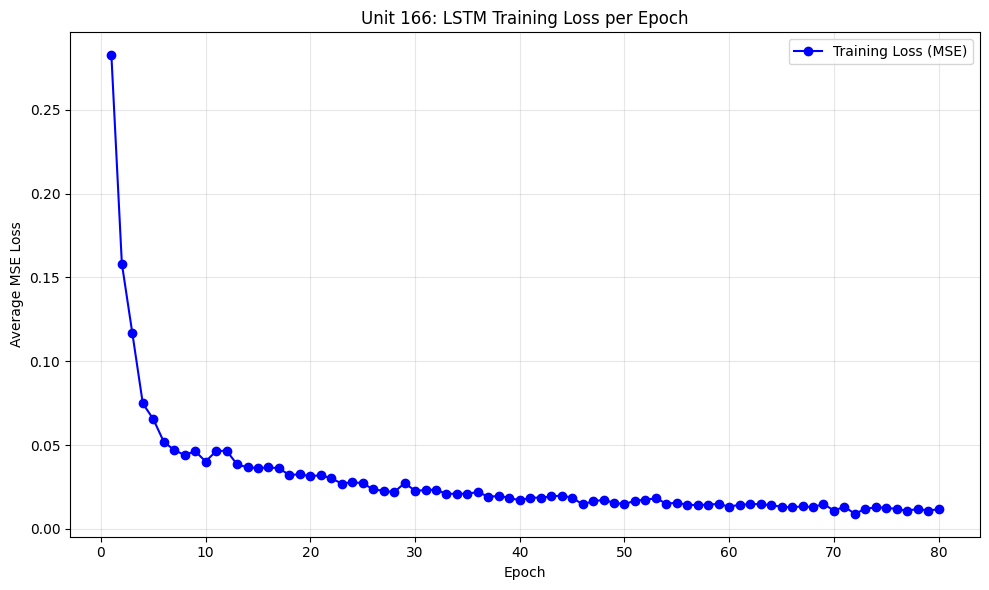

Plotting predictions on train/test split...


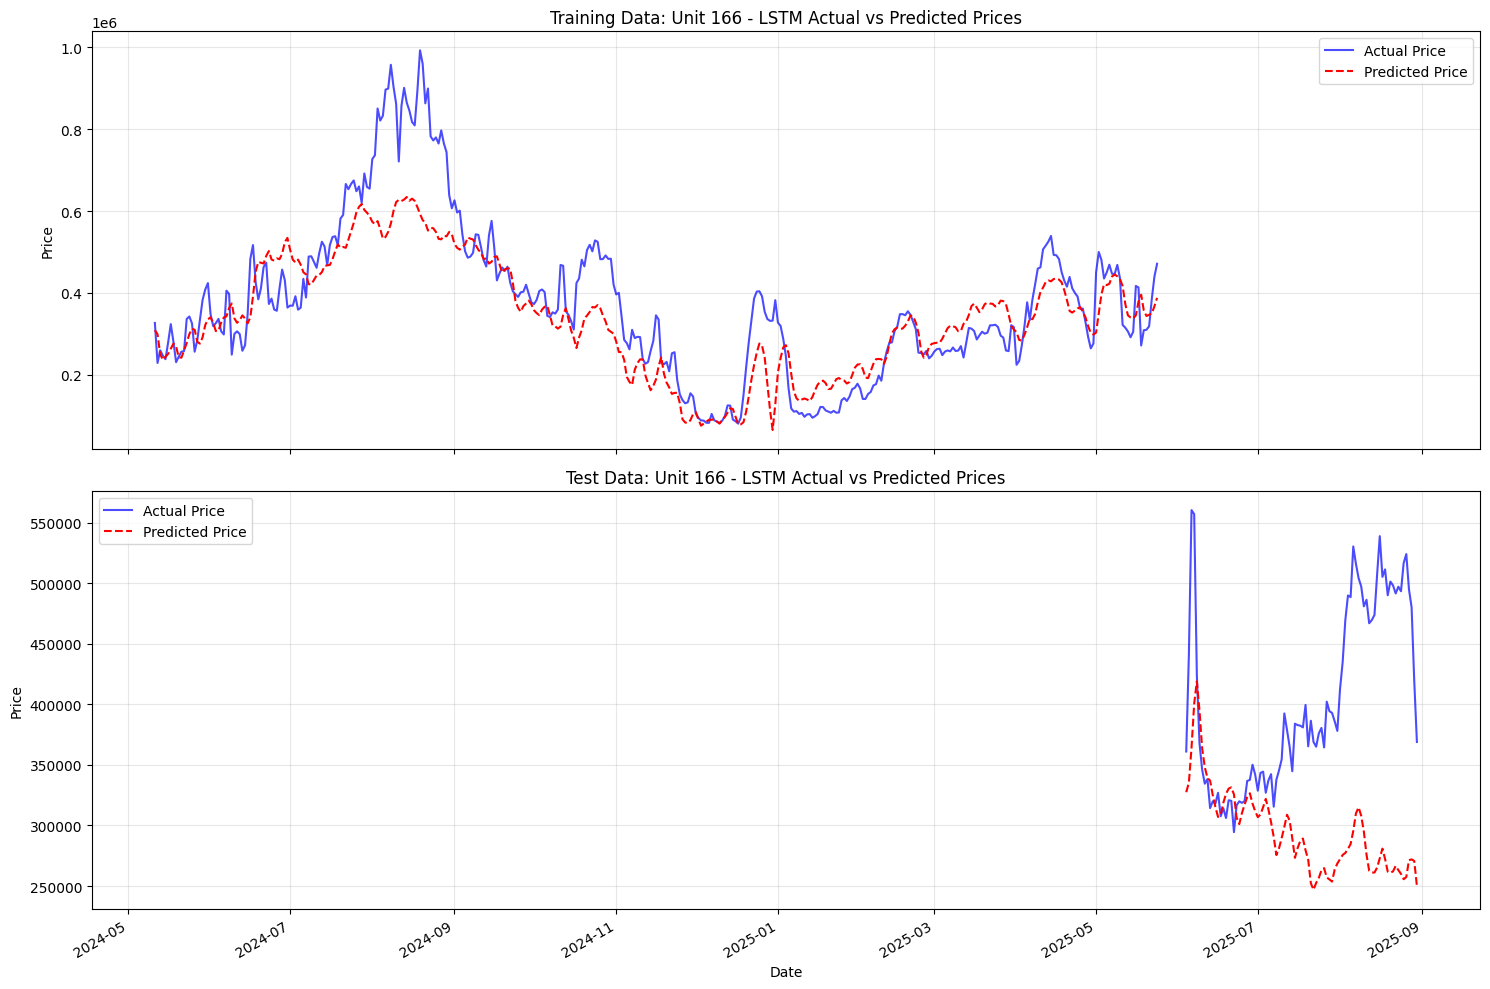

Plotting predictions on the full unit DataFrame...


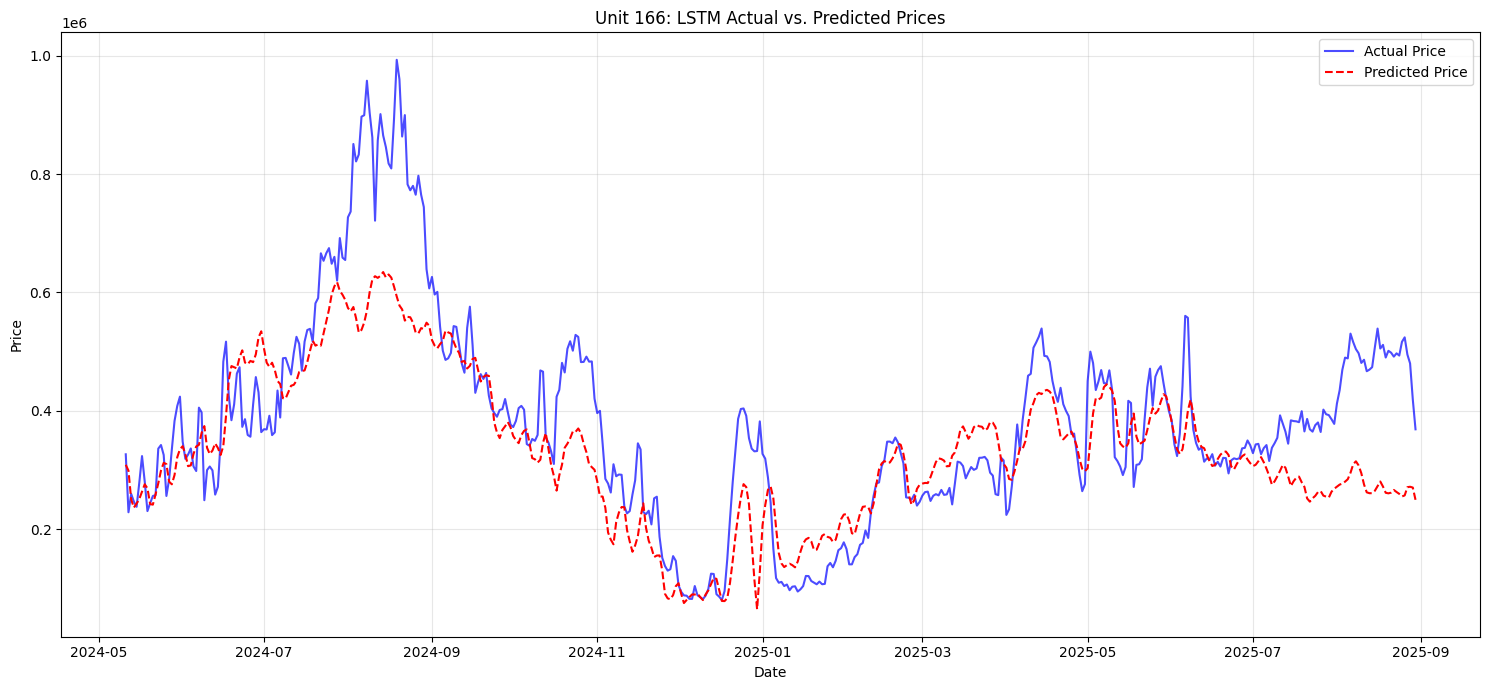


[Step 4/4] Pipeline finished for Unit 166.
--- End LSTM Pipeline ---
--- Starting LSTM Pipeline for Unit 167 (predicting Price) ---

[Step 1/4] Splitting data with test_size=0.2...
Split complete. Test size: 0.20
Target column: total_price_167
Training set range: 2024-05-01 00:00:00 to 2025-05-24 00:00:00 (389 samples)
Testing set range: 2025-05-25 00:00:00 to 2025-08-30 00:00:00 (98 samples)

[Step 2/4] Training and evaluating LSTM model...

Training LSTM model for target: total_price_167 (predicting Price)
Hyperparameters: seq_len=10, batch=16, epochs=80, lr=0.001
Features used (X): ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'taux_occupation_167']

Starting Training...


Epoch [10/80], Loss: 0.033203


Epoch [20/80], Loss: 0.025185


Epoch [30/80], Loss: 0.020626


Epoch [40/80], Loss: 0.018551


Epoch [50/80], Loss: 0.016336


Epoch [60/80], Loss: 0.016106


Epoch [70/80], Loss: 0.015191


Epoch [80/80], Loss: 0.014760
Training Finished.

Model Evaluation Metrics for Price prediction:
Train RMSE: 9562.32
Test RMSE: 7200.96
Train MAE: 6595.64
Test MAE: 6089.38
Train R²: 0.5180
Test R²: 0.4233

[Step 3/4] Plotting results...
Plotting training loss...


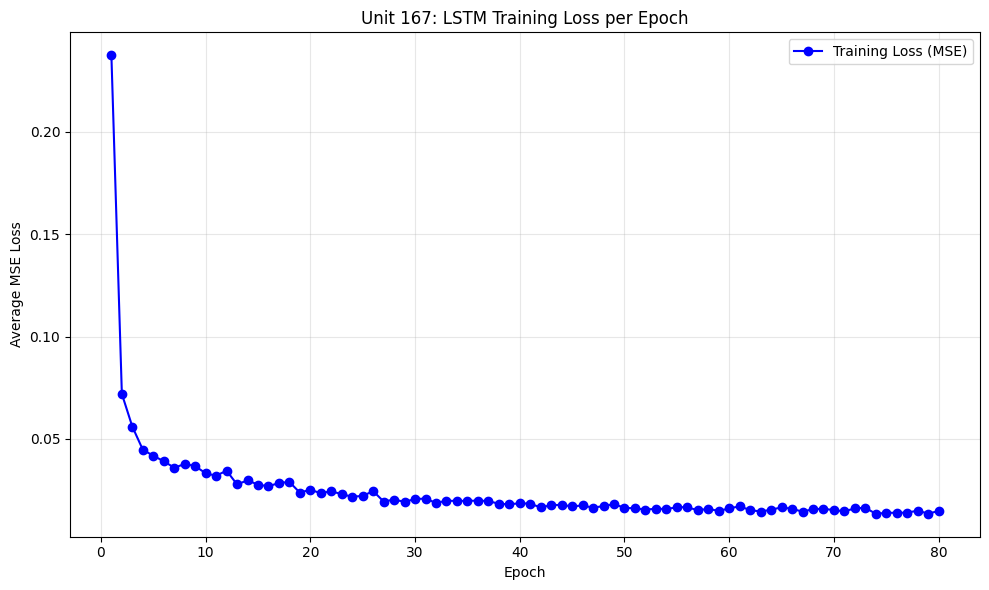

Plotting predictions on train/test split...


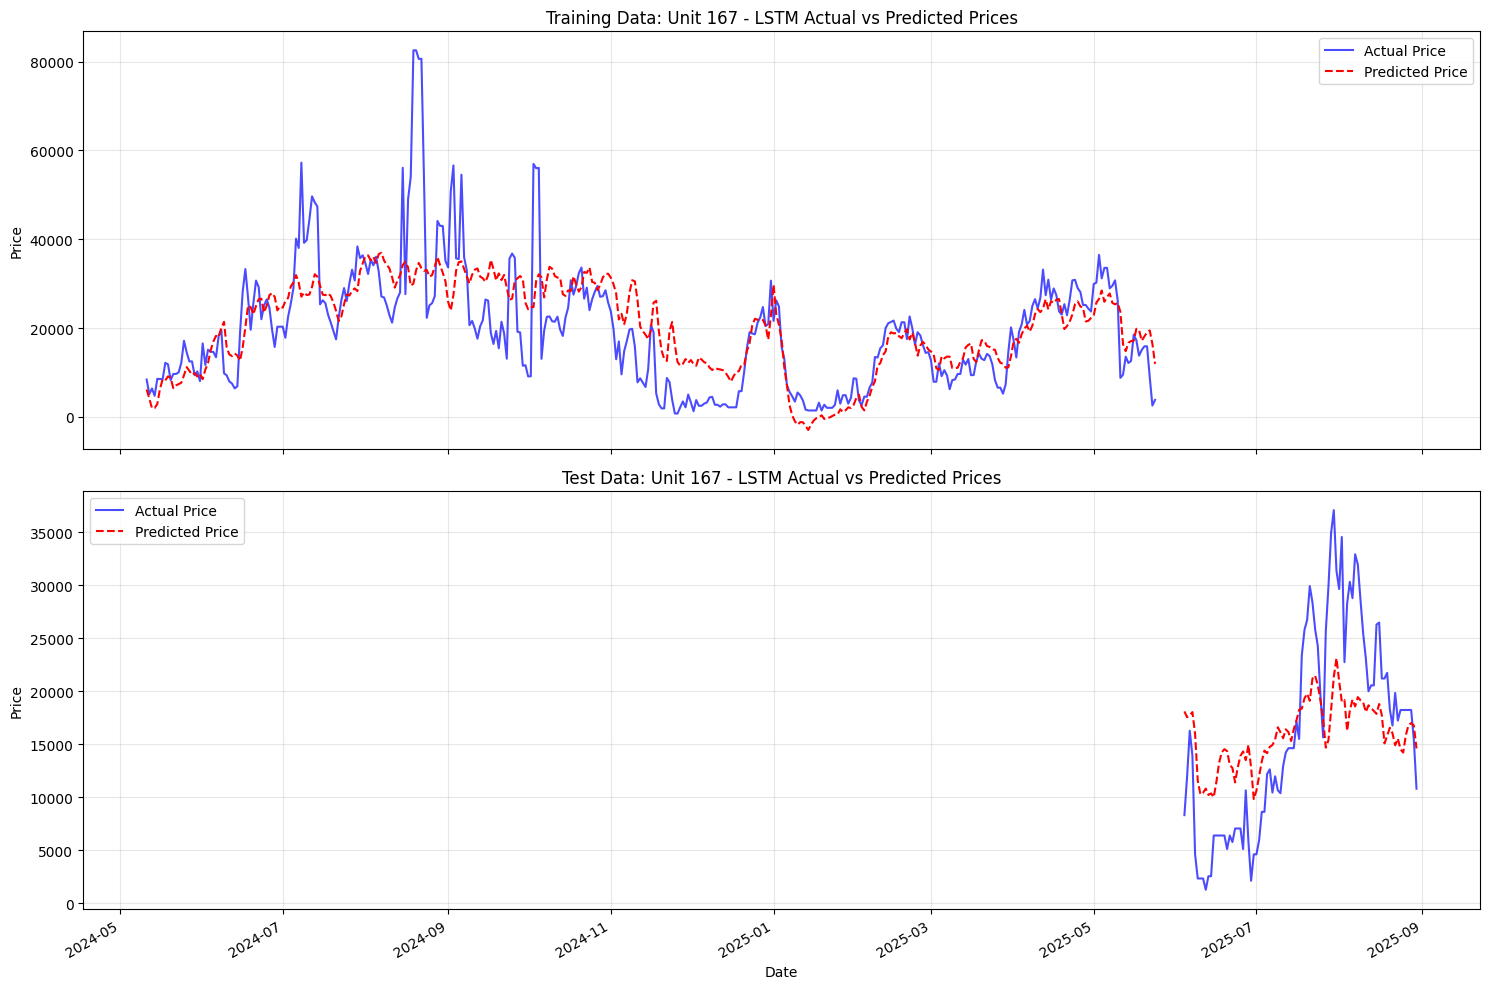

Plotting predictions on the full unit DataFrame...


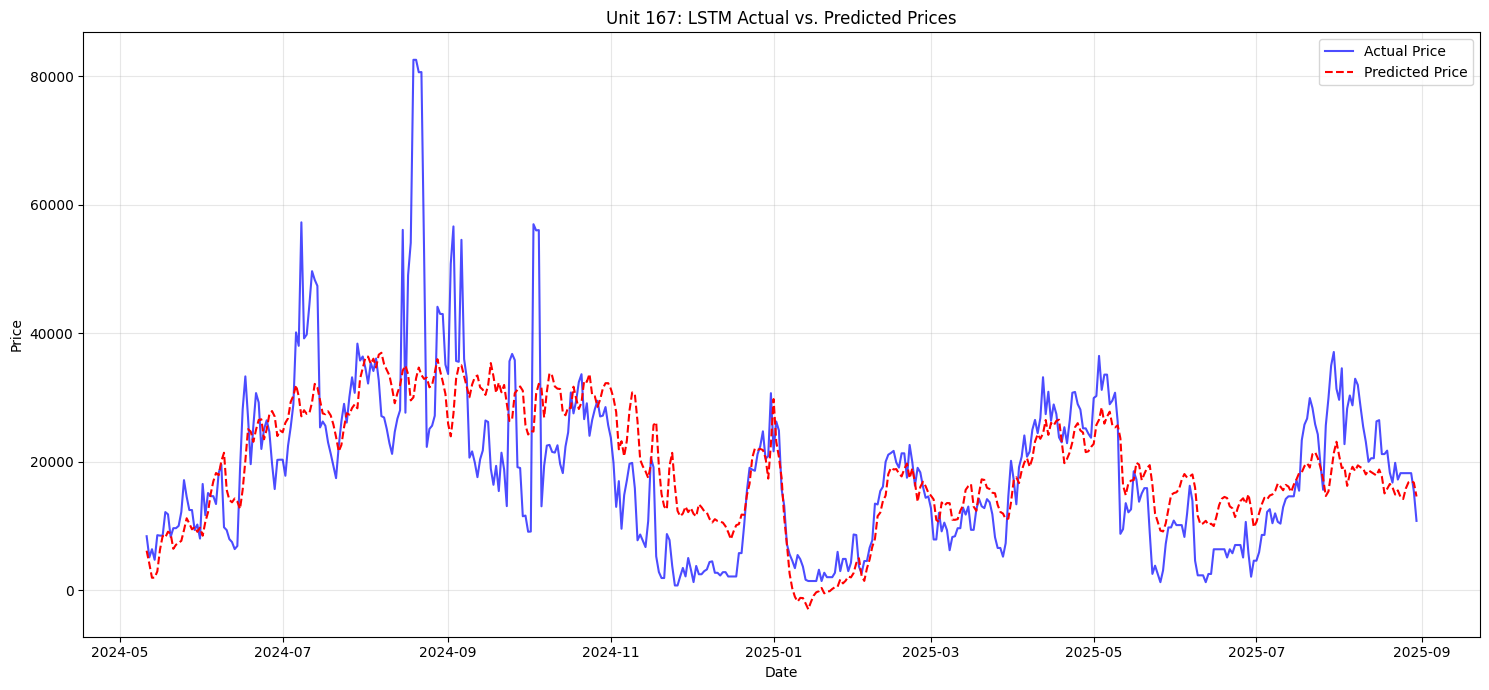


[Step 4/4] Pipeline finished for Unit 167.
--- End LSTM Pipeline ---


In [25]:
lstm_results_price_166 = run_lstm_pipeline(
    df_166,
    '166',
    test_size=0.2,
    sequence_length=10, 
    epochs=80,
    target_type='price'
)

lstm_results_price_167 = run_lstm_pipeline(
    df_167,
    '167',
    test_size=0.2,
    sequence_length=10, 
    epochs=80,
    target_type='price'
)

In [27]:
save_lstm_model(
    lstm_results=lstm_results_price_166,
    folder_path=metadata['LSTMModelsV2']['price_166']['folder_path'],
    model_name=metadata['LSTMModelsV2']['price_166']['model_name'],
)

save_lstm_model(
    lstm_results=lstm_results_price_167,
    folder_path=metadata['LSTMModelsV2']['price_167']['folder_path'],
    model_name=metadata['LSTMModelsV2']['price_167']['model_name'],
)

Created directory: ../TrainedModels/UnitsBasedModelsV2/PredictPrice/LSTMModels
Model state dictionary successfully saved to ../TrainedModels/UnitsBasedModelsV2/PredictPrice/LSTMModels\lstm_v2_model_166_price_model_state_dict.pth
Feature scaler successfully saved to ../TrainedModels/UnitsBasedModelsV2/PredictPrice/LSTMModels\lstm_v2_model_166_price_feature_scaler.pkl
Target scaler successfully saved to ../TrainedModels/UnitsBasedModelsV2/PredictPrice/LSTMModels\lstm_v2_model_166_price_target_scaler.pkl
Model metadata saved to ../TrainedModels/UnitsBasedModelsV2/PredictPrice/LSTMModels\lstm_v2_model_166_price_metadata.json
Model state dictionary successfully saved to ../TrainedModels/UnitsBasedModelsV2/PredictPrice/LSTMModels\lstm_v2_model_167_price_model_state_dict.pth
Feature scaler successfully saved to ../TrainedModels/UnitsBasedModelsV2/PredictPrice/LSTMModels\lstm_v2_model_167_price_feature_scaler.pkl
Target scaler successfully saved to ../TrainedModels/UnitsBasedModelsV2/PredictPr

{'model_state_dict': '../TrainedModels/UnitsBasedModelsV2/PredictPrice/LSTMModels\\lstm_v2_model_167_price_model_state_dict.pth',
 'feature_scaler': '../TrainedModels/UnitsBasedModelsV2/PredictPrice/LSTMModels\\lstm_v2_model_167_price_feature_scaler.pkl',
 'target_scaler': '../TrainedModels/UnitsBasedModelsV2/PredictPrice/LSTMModels\\lstm_v2_model_167_price_target_scaler.pkl',
 'metadata': '../TrainedModels/UnitsBasedModelsV2/PredictPrice/LSTMModels\\lstm_v2_model_167_price_metadata.json'}

In [30]:
results_lstm = find_max_output_for_date_range_lstm(
    start_date_str='2025-04-20',
    end_date_str='2025-04-30',
    unit_id='166',
    min_value=30.0,
    max_value=100.0,
    step=1,
    df_166=df_166,
    df_167=df_167,
    target_type='price',
    modelsName='LSTMModelsV2'
)


Processing date: 2025-04-20 for LSTM...
Loading model for target='price', unit='166'...
Model name: lstm_v2_model_166_price
Metadata successfully loaded from ../TrainedModels/UnitsBasedModelsV2/PredictPrice/LSTMModels\lstm_v2_model_166_price_metadata.json
Target column extracted: total_price_166
Target type extracted: price
LSTMModel instantiated with parameters from metadata.
Model state dictionary successfully loaded from ../TrainedModels/UnitsBasedModelsV2/PredictPrice/LSTMModels\lstm_v2_model_166_price_model_state_dict.pth onto cpu
Feature scaler successfully loaded from ../TrainedModels/UnitsBasedModelsV2/PredictPrice/LSTMModels\lstm_v2_model_166_price_feature_scaler.pkl
Target scaler successfully loaded from ../TrainedModels/UnitsBasedModelsV2/PredictPrice/LSTMModels\lstm_v2_model_166_price_target_scaler.pkl

Loading process finished.
Model loaded successfully.

Searching for optimal taux input that maximizes price
for LSTM model (unit 166) on 2025-04-20...
Range: 30.0-100.0, st

Testing taux_occupation values:  17%|█▋        | 12/71 [00:00<00:00, 113.22it/s]


--- Predicting price for Unit 166 on 2025-04-20 ---
Generated features for target date: {'dayofweek': 6, 'month': 4, 'year': 2025, 'dayofyear': 110, 'weekofyear': 16, 'taux_occupation_166': 30.0}
Fetching history from 2025-04-11 to 2025-04-19
Expected feature order: ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'taux_occupation_166']
Scaling sequence of shape: (10, 6)
Input tensor shape: torch.Size([1, 10, 6])
Scaled prediction shape: torch.Size([1, 1])
Predicted price (Unit 166) for 2025-04-20: 277914.12

--- Predicting price for Unit 166 on 2025-04-20 ---
Generated features for target date: {'dayofweek': 6, 'month': 4, 'year': 2025, 'dayofyear': 110, 'weekofyear': 16, 'taux_occupation_166': 31.0}
Fetching history from 2025-04-11 to 2025-04-19
Expected feature order: ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'taux_occupation_166']
Scaling sequence of shape: (10, 6)
Input tensor shape: torch.Size([1, 10, 6])
Scaled prediction shape: torch.Size([1, 1])
Predi

Testing taux_occupation values:  51%|█████     | 36/71 [00:00<00:00, 114.73it/s]


Scaled prediction shape: torch.Size([1, 1])
Predicted price (Unit 166) for 2025-04-20: 311978.03

--- Predicting price for Unit 166 on 2025-04-20 ---
Generated features for target date: {'dayofweek': 6, 'month': 4, 'year': 2025, 'dayofyear': 110, 'weekofyear': 16, 'taux_occupation_166': 53.0}
Fetching history from 2025-04-11 to 2025-04-19
Expected feature order: ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'taux_occupation_166']
Scaling sequence of shape: (10, 6)
Input tensor shape: torch.Size([1, 10, 6])
Scaled prediction shape: torch.Size([1, 1])
Predicted price (Unit 166) for 2025-04-20: 313563.94

--- Predicting price for Unit 166 on 2025-04-20 ---
Generated features for target date: {'dayofweek': 6, 'month': 4, 'year': 2025, 'dayofyear': 110, 'weekofyear': 16, 'taux_occupation_166': 54.0}
Fetching history from 2025-04-11 to 2025-04-19
Expected feature order: ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'taux_occupation_166']
Scaling sequence of shape: (1

...

Scaled prediction shape: torch.Size([1, 1])
Predicted price (Unit 166) for 2025-04-30: 314957.12

--- Predicting price for Unit 166 on 2025-04-30 ---
Generated features for target date: {'dayofweek': 2, 'month': 4, 'year': 2025, 'dayofyear': 120, 'weekofyear': 18, 'taux_occupation_166': 68.0}
Fetching history from 2025-04-21 to 2025-04-29
Expected feature order: ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'taux_occupation_166']
Scaling sequence of shape: (10, 6)
Input tensor shape: torch.Size([1, 10, 6])
Scaled prediction shape: torch.Size([1, 1])
Predicted price (Unit 166) for 2025-04-30: 316443.97

--- Predicting price for Unit 166 on 2025-04-30 ---
Generated features for target date: {'dayofweek': 2, 'month': 4, 'year': 2025, 'dayofyear': 120, 'weekofyear': 18, 'taux_occupation_166': 69.0}
Fetching history from 2025-04-21 to 2025-04-29
Expected feature order: ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'taux_occupation_166']
Scaling sequence of shape: (10

Testing taux_occupation values:  72%|███████▏  | 51/71 [00:00<00:00, 94.41it/s]

Scaled prediction shape: torch.Size([1, 1])
Predicted price (Unit 166) for 2025-04-30: 319426.47

--- Predicting price for Unit 166 on 2025-04-30 ---
Generated features for target date: {'dayofweek': 2, 'month': 4, 'year': 2025, 'dayofyear': 120, 'weekofyear': 18, 'taux_occupation_166': 71.0}
Fetching history from 2025-04-21 to 2025-04-29
Expected feature order: ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'taux_occupation_166']
Scaling sequence of shape: (10, 6)
Input tensor shape: torch.Size([1, 10, 6])
Scaled prediction shape: torch.Size([1, 1])
Predicted price (Unit 166) for 2025-04-30: 320922.19

--- Predicting price for Unit 166 on 2025-04-30 ---
Generated features for target date: {'dayofweek': 2, 'month': 4, 'year': 2025, 'dayofyear': 120, 'weekofyear': 18, 'taux_occupation_166': 72.0}
Fetching history from 2025-04-21 to 2025-04-29
Expected feature order: ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'taux_occupation_166']
Scaling sequence of shape: (10

Testing taux_occupation values: 100%|██████████| 71/71 [00:00<00:00, 92.44it/s]

Expected feature order: ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'taux_occupation_166']
Scaling sequence of shape: (10, 6)
Input tensor shape: torch.Size([1, 10, 6])
Scaled prediction shape: torch.Size([1, 1])
Predicted price (Unit 166) for 2025-04-30: 349895.38

--- Predicting price for Unit 166 on 2025-04-30 ---
Generated features for target date: {'dayofweek': 2, 'month': 4, 'year': 2025, 'dayofyear': 120, 'weekofyear': 18, 'taux_occupation_166': 91.0}
Fetching history from 2025-04-21 to 2025-04-29
Expected feature order: ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'taux_occupation_166']
Scaling sequence of shape: (10, 6)
Input tensor shape: torch.Size([1, 10, 6])
Scaled prediction shape: torch.Size([1, 1])
Predicted price (Unit 166) for 2025-04-30: 351449.59

--- Predicting price for Unit 166 on 2025-04-30 ---
Generated features for target date: {'dayofweek': 2, 'month': 4, 'year': 2025, 'dayofyear': 120, 'weekofyear': 18, 'taux_occupation_166': 92.0}

In [31]:
results_lstm

{'2025-04-20': {'best_input': 100.0, 'max_output': 391802.06},
 '2025-04-21': {'best_input': 100.0, 'max_output': 379784.56},
 '2025-04-22': {'best_input': 100.0, 'max_output': 390272.47},
 '2025-04-23': {'best_input': 100.0, 'max_output': 397055.72},
 '2025-04-24': {'best_input': 100.0, 'max_output': 401324.78},
 '2025-04-25': {'best_input': 100.0, 'max_output': 399411.28},
 '2025-04-26': {'best_input': 100.0, 'max_output': 386262.97},
 '2025-04-27': {'best_input': 100.0, 'max_output': 372714.88},
 '2025-04-28': {'best_input': 100.0, 'max_output': 363500.62},
 '2025-04-29': {'best_input': 100.0, 'max_output': 364197.03},
 '2025-04-30': {'best_input': 100.0, 'max_output': 365569.12}}